# Policy Gradient RL on Long-Tailed CIFAR-10 (Pure RL, No SAT)

This notebook implements **pure Reinforcement Learning (Policy Gradient)** for long-tailed classification **without SAT loss**.

**Key Innovation:**
- **Policy Network**: MLP that learns optimal sample weighting policy
- **REINFORCE Algorithm**: Policy gradient with baseline to reduce variance
- **Dynamic Curriculum**: RL agent adjusts class weights based on training progress
- **Reward Shaping**: Optimizes for balanced and worst-group accuracy
- **Standard Cross-Entropy Loss**: No SAT soft labels, pure supervised learning

**Addresses Long-Tail Weaknesses:**
1. ✅ Poor tail class learning → Adaptive curriculum prioritizes struggling classes
2. ✅ Class imbalance → Dynamic reweighting based on performance feedback
3. ✅ Catastrophic forgetting → Policy learns to maintain head class performance
4. ✅ Training inefficiency → Intelligent sampling reduces wasted updates

**Settings:**
- Architecture: VGG-16 with Batch Normalization
- Dataset: CIFAR-10 Long-Tailed (IR=100)
- Loss: **Standard Cross-Entropy** (no SAT)
- RL Framework: Policy Gradient (REINFORCE) with entropy regularization
- State Space: [class_accuracies, class_confidences, class_losses, training_progress]
- Action Space: Class weights for sampling (continuous, 10-dimensional)
- Reward: Δ(balanced_accuracy) + 2.0 × Δ(worst_group_accuracy)

## 1. Setup and Imports

In [8]:
import os
import time
import random
import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from PIL import Image

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# ============================================================================
# EMBEDDED UTILITY CLASSES
# ============================================================================

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)

    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))

    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res


# ============================================================================
# VGG-16 MODEL
# ============================================================================

class VGG(nn.Module):
    def __init__(self, features, num_classes=1000, input_size=32):
        super(VGG, self).__init__()
        self.features = features
        if input_size == 32:
            self.classifier = nn.Sequential(
                nn.Linear(512, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        elif input_size == 64:
            self.classifier = nn.Sequential(
                nn.Linear(2048, 512), nn.ReLU(inplace=True),
                nn.BatchNorm1d(512), nn.Dropout2d(0.5),
                nn.Linear(512, num_classes)
            )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                n = m.weight.size(1)
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


def make_layers(cfg, batch_norm=False):
    layers = []
    in_channels = 3
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        elif type(v) == int:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.ReLU(inplace=True), nn.BatchNorm2d(v)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
        elif type(v) == float:
            layers += [nn.Dropout2d(v)]
    return nn.Sequential(*layers)


cfg_vgg16 = {
    'D': [64, 0.3, 64, 'M', 128, 0.4, 128, 'M', 256, 0.4, 256, 0.4, 256, 'M',
          512, 0.4, 512, 0.4, 512, 'M', 512, 0.4, 512, 0.4, 512, 'M', 0.5]
}


def vgg16_bn(num_classes=1000, input_size=32, **kwargs):
    """VGG 16-layer model with batch normalization"""
    model = VGG(make_layers(cfg_vgg16['D'], batch_norm=True), 
                num_classes=num_classes, input_size=input_size, **kwargs)
    return model


print("✅ All utility classes and VGG-16 model embedded successfully!")
print("⚠️  Note: Using standard Cross-Entropy loss (NO SAT)")

PyTorch version: 2.0.1+cu117
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3060
✅ All utility classes and VGG-16 model embedded successfully!
⚠️  Note: Using standard Cross-Entropy loss (NO SAT)


## 2. Reinforcement Learning Components: Policy Network & Agent

In [9]:
# ============================================================================
# POLICY GRADIENT RL COMPONENTS (Fixed and Stabilized)
# ============================================================================

class PolicyNetwork(nn.Module):
    """
    Policy network that learns optimal class weighting strategy
    
    State space (41-dimensional):
    - class_accuracies (10): Current accuracy for each class (normalized to 0-1)
    - class_confidences (10): Average prediction confidence per class (0-1)
    - class_losses (10): Average loss per class (normalized)
    - class_counts (10): Number of samples seen per class (normalized)
    - epoch_progress (1): Current training progress (0-1)
    
    Action space (10-dimensional):
    - class_weights: Sampling weights for each class (continuous, 0-1)
    """
    
    def __init__(self, state_dim=41, action_dim=10, hidden_dims=[128, 64]):
        super(PolicyNetwork, self).__init__()
        
        self.action_dim = action_dim
        
        layers = []
        input_dim = state_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.LayerNorm(hidden_dim),  # LayerNorm for stability
                nn.ReLU(),
                nn.Dropout(0.1)  # Reduced dropout
            ])
            input_dim = hidden_dim
        
        # Output layer
        self.network = nn.Sequential(*layers)
        self.output_layer = nn.Linear(input_dim, action_dim)
        
        # Initialize weights properly
        self._initialize_weights()
        
    def _initialize_weights(self):
        """Initialize weights with smaller values for stability"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.1)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)
        
    def forward(self, state):
        """
        Forward pass with input validation
        """
        # Check for NaN in input
        if torch.any(torch.isnan(state)) or torch.any(torch.isinf(state)):
            # Return uniform distribution if input is invalid
            batch_size = state.shape[0] if len(state.shape) > 1 else 1
            device = state.device
            return torch.ones(batch_size, self.action_dim, device=device) / self.action_dim
        
        features = self.network(state)
        logits = self.output_layer(features)
        
        # Clamp logits to prevent overflow in softmax
        logits = torch.clamp(logits, min=-10, max=10)
        
        # Softmax to ensure weights sum to 1 and are positive
        weights = F.softmax(logits, dim=-1)
        
        return weights
    
    def get_log_prob(self, state, action):
        """
        Calculate log probability of action given state
        Uses stable computation
        """
        weights = self.forward(state)
        
        # Ensure action is normalized
        action = action / (action.sum(dim=-1, keepdim=True) + 1e-8)
        
        # Use log for numerical stability
        log_weights = torch.log(weights + 1e-8)
        
        # Cross-entropy style: sum(action * log(weights))
        action_log_prob = (action * log_weights).sum(dim=-1)
        
        return action_log_prob


class RLAgent:
    """
    Reinforcement Learning agent using REINFORCE (Policy Gradient)
    
    Training loop:
    1. Observe current state (class performance metrics)
    2. Policy network outputs class weights
    3. Train model for N epochs with weighted sampling
    4. Calculate reward (improvement in balanced/worst accuracy)
    5. Update policy using policy gradient
    """
    
    def __init__(self, policy_net, learning_rate=3e-4, gamma=0.95, entropy_coef=0.05):
        """
        Args:
            policy_net: PolicyNetwork instance
            learning_rate: Learning rate for policy optimization
            gamma: Discount factor for future rewards
            entropy_coef: Coefficient for entropy regularization (exploration)
        """
        self.policy_net = policy_net
        self.optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate, weight_decay=1e-5)
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        
        # Experience buffer for one episode
        self.states = []
        self.actions = []
        self.rewards = []
        
        # Baseline for variance reduction (moving average of returns)
        self.baseline = 0.0
        self.baseline_momentum = 0.9
        
        # Track number of updates for debugging
        self.update_count = 0
    
    def select_action(self, state, exploration_noise=0.1):
        """
        Select action (class weights) given current state
        
        Args:
            state: Numpy array of shape (state_dim,)
            exploration_noise: Amount of noise to add for exploration
        
        Returns:
            action: Numpy array of shape (action_dim,) - class weights (validated)
        """
        # Validate state
        state = np.nan_to_num(state, nan=0.0, posinf=1.0, neginf=0.0)
        state = np.clip(state, 0.0, 1.0)
        
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        if torch.cuda.is_available():
            state_tensor = state_tensor.cuda()
        
        with torch.no_grad():
            action = self.policy_net(state_tensor).squeeze(0).cpu().numpy()
        
        # Add exploration noise (Dirichlet noise like in AlphaZero)
        if exploration_noise > 0:
            noise = np.random.dirichlet(np.ones(len(action)) * 0.3)
            action = (1 - exploration_noise) * action + exploration_noise * noise
        
        # Validate and normalize action
        action = np.nan_to_num(action, nan=0.1, posinf=0.1, neginf=0.1)
        action = np.clip(action, 0.01, 1.0)  # Minimum weight of 1%
        action = action / action.sum()  # Normalize
        
        return action
    
    def store_transition(self, state, action, reward):
        """Store experience for policy update"""
        # Validate before storing
        state = np.nan_to_num(state, nan=0.0, posinf=1.0, neginf=0.0)
        action = np.nan_to_num(action, nan=0.1, posinf=0.1, neginf=0.1)
        reward = np.clip(reward, -10, 10)
        
        self.states.append(state.copy())
        self.actions.append(action.copy())
        self.rewards.append(float(reward))
    
    def update_policy(self):
        """
        Update policy using REINFORCE algorithm with comprehensive error handling
        """
        if len(self.states) == 0:
            return 0.0
        
        try:
            self.update_count += 1
            
            # Convert to tensors with validation
            states_np = np.array(self.states, dtype=np.float32)
            actions_np = np.array(self.actions, dtype=np.float32)
            
            # Validate arrays
            states_np = np.nan_to_num(states_np, nan=0.0, posinf=1.0, neginf=0.0)
            actions_np = np.nan_to_num(actions_np, nan=0.1, posinf=0.1, neginf=0.1)
            
            # Normalize actions
            actions_np = actions_np / (actions_np.sum(axis=-1, keepdims=True) + 1e-8)
            
            states = torch.FloatTensor(states_np)
            actions = torch.FloatTensor(actions_np)
            
            if torch.cuda.is_available():
                states = states.cuda()
                actions = actions.cuda()
            
            # Calculate discounted returns (G_t)
            returns = []
            G = 0
            for r in reversed(self.rewards):
                r = np.clip(r, -10, 10)  # Clip rewards
                G = r + self.gamma * G
                returns.insert(0, G)
            returns = torch.FloatTensor(returns)
            if torch.cuda.is_available():
                returns = returns.cuda()
            
            # Normalize returns for stability (only if std > 0)
            returns_std = returns.std()
            if returns_std > 1e-8:
                returns = (returns - returns.mean()) / (returns_std + 1e-8)
            else:
                returns = returns - returns.mean()
            
            # Update baseline (moving average)
            self.baseline = self.baseline_momentum * self.baseline + \
                           (1 - self.baseline_momentum) * returns.mean().item()
            
            # Calculate policy loss
            log_probs = self.policy_net.get_log_prob(states, actions)
            
            # Check for NaN in log_probs
            if torch.any(torch.isnan(log_probs)) or torch.any(torch.isinf(log_probs)):
                print("⚠️  Warning: NaN/Inf in log_probs, skipping policy update")
                self._clear_buffer()
                return 0.0
            
            # Advantage = return - baseline
            advantages = returns - self.baseline
            
            # Policy gradient loss
            policy_loss = -(log_probs * advantages).mean()
            
            # Entropy regularization (encourage exploration)
            action_probs = self.policy_net(states)
            entropy = -(action_probs * torch.log(action_probs + 1e-8)).sum(dim=-1).mean()
            
            # Total loss
            total_loss = policy_loss - self.entropy_coef * entropy
            
            # Check for NaN in loss
            if torch.isnan(total_loss) or torch.isinf(total_loss):
                print("⚠️  Warning: NaN/Inf in policy loss, skipping update")
                self._clear_buffer()
                return 0.0
            
            # Optimize
            self.optimizer.zero_grad()
            total_loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=0.5)
            
            # Check for NaN in gradients
            has_nan_grad = False
            for param in self.policy_net.parameters():
                if param.grad is not None:
                    if torch.any(torch.isnan(param.grad)) or torch.any(torch.isinf(param.grad)):
                        has_nan_grad = True
                        break
            
            if not has_nan_grad:
                self.optimizer.step()
            else:
                print("⚠️  Warning: NaN/Inf in gradients, skipping optimizer step")
            
            # Clear buffer
            self._clear_buffer()
            
            return total_loss.item()
            
        except Exception as e:
            print(f"⚠️  Warning: Policy update failed: {e}")
            self._clear_buffer()
            return 0.0
    
    def _clear_buffer(self):
        """Clear experience buffer"""
        self.states = []
        self.actions = []
        self.rewards = []
    
    def get_state(self, class_stats, epoch, total_epochs):
        """
        Construct state vector from current training statistics
        All features are normalized to [0, 1] range for stability
        
        Args:
            class_stats: Dict with keys 'accuracies', 'confidences', 'losses', 'counts'
            epoch: Current epoch number
            total_epochs: Total number of epochs
        
        Returns:
            state: Numpy array of shape (state_dim,)
        """
        # Normalize accuracies from [0, 100] to [0, 1]
        accuracies = np.array(class_stats['accuracies'], dtype=np.float32) / 100.0
        
        # Confidences are already in [0, 1]
        confidences = np.array(class_stats['confidences'], dtype=np.float32)
        
        # Normalize losses - use sigmoid-like transformation to bound to [0, 1]
        losses = np.array(class_stats['losses'], dtype=np.float32)
        losses = 1.0 / (1.0 + np.exp(-losses + 2))  # Shifted sigmoid, typical CE loss ~2
        
        # Counts are already normalized
        counts = np.array(class_stats['counts'], dtype=np.float32)
        
        # Epoch progress
        progress = np.array([epoch / max(total_epochs, 1)], dtype=np.float32)
        
        state = np.concatenate([accuracies, confidences, losses, counts, progress])
        
        # Replace any NaN or Inf with 0
        state = np.nan_to_num(state, nan=0.0, posinf=1.0, neginf=0.0)
        
        # Clip to valid range
        state = np.clip(state, 0.0, 1.0)
        
        return state.astype(np.float32)


print("✅ RL components (PolicyNetwork, RLAgent) implemented!")
print("⚠️  Using standard Cross-Entropy as loss function (NO SAT)")
print("🔧 Includes: LayerNorm, gradient clipping, NaN handling, exploration noise")

✅ RL components (PolicyNetwork, RLAgent) implemented!
⚠️  Using standard Cross-Entropy as loss function (NO SAT)
🔧 Includes: LayerNorm, gradient clipping, NaN handling, exploration noise


## 3. Configuration

In [10]:
# Configuration
class Config:
    # Dataset settings
    dataset = 'cifar10'
    imbalance_ratio = 100
    
    # Architecture
    arch = 'vgg16_bn'
    
    # RL settings
    rl_enabled = True
    rl_update_freq = 5         # Update policy every N epochs
    rl_state_dim = 41          # State space dimension
    rl_action_dim = 10         # Action space dimension (num_classes)
    rl_learning_rate = 3e-4    # Learning rate for policy network (increased)
    rl_gamma = 0.95            # Discount factor (reduced for shorter horizon)
    rl_entropy_coef = 0.05     # Entropy regularization (increased for more exploration)
    
    # Reward shaping
    reward_balanced_coef = 1.0   # Weight for balanced accuracy improvement
    reward_worst_coef = 3.0      # Weight for worst-group accuracy improvement (increased)
    
    # Training settings
    epochs = 300
    batch_size_train = 128
    batch_size_test = 200
    
    # Standard SGD settings
    lr = 0.1
    momentum = 0.9
    weight_decay = 5e-4
    gamma = 0.5
    schedule = [25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275]
    
    # Evaluation settings
    expected_coverage = [100., 99., 98., 97., 95., 90., 85., 80., 75., 70., 60., 50., 40., 30., 20., 10.]
    
    # System settings
    gpu_id = '0'
    num_workers = 4
    manual_seed = 42
    save_dir = './checkpoints/policyrl_longtailed_ir100'
    
config = Config()

# Reproducibility settings
random.seed(config.manual_seed)
torch.manual_seed(config.manual_seed)
np.random.seed(config.manual_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.manual_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print(f"Warning: torch.use_deterministic_algorithms not available: {e}")

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

os.environ['CUDA_VISIBLE_DEVICES'] = config.gpu_id
use_cuda = torch.cuda.is_available()
os.makedirs(config.save_dir, exist_ok=True)

print("🔒 Reproducibility settings enabled")
print(f"\nPolicy Gradient RL Configuration (Pure RL, No SAT):")
print(f"  Architecture: {config.arch}")
print(f"  Loss: Standard Cross-Entropy")
print(f"  RL Framework: REINFORCE (Policy Gradient)")
print(f"  Policy update frequency: every {config.rl_update_freq} epochs")
print(f"  Reward: {config.reward_balanced_coef}×Δ(bal) + {config.reward_worst_coef}×Δ(worst)")
print(f"  State dim: {config.rl_state_dim}, Action dim: {config.rl_action_dim}")
print(f"  Dataset: Long-Tailed CIFAR-10 (IR={config.imbalance_ratio})")
print(f"  Save directory: {config.save_dir}")

🔒 Reproducibility settings enabled

Policy Gradient RL Configuration (Pure RL, No SAT):
  Architecture: vgg16_bn
  Loss: Standard Cross-Entropy
  RL Framework: REINFORCE (Policy Gradient)
  Policy update frequency: every 5 epochs
  Reward: 1.0×Δ(bal) + 3.0×Δ(worst)
  State dim: 41, Action dim: 10
  Dataset: Long-Tailed CIFAR-10 (IR=100)
  Save directory: ./checkpoints/policyrl_longtailed_ir100


## 4. Dataset Preparation (Same as Baseline)

Creating Long-Tailed CIFAR-10 programmatically (IR=100)...
Files already downloaded and verified
Files already downloaded and verified
Creating long-tailed distribution...
Target samples per class: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]
Total selected training samples: 12406

✅ Dataset created successfully!
Training samples: 12406 (imbalanced)
Test samples: 10000 (balanced)
RL-guided weighted sampling enabled


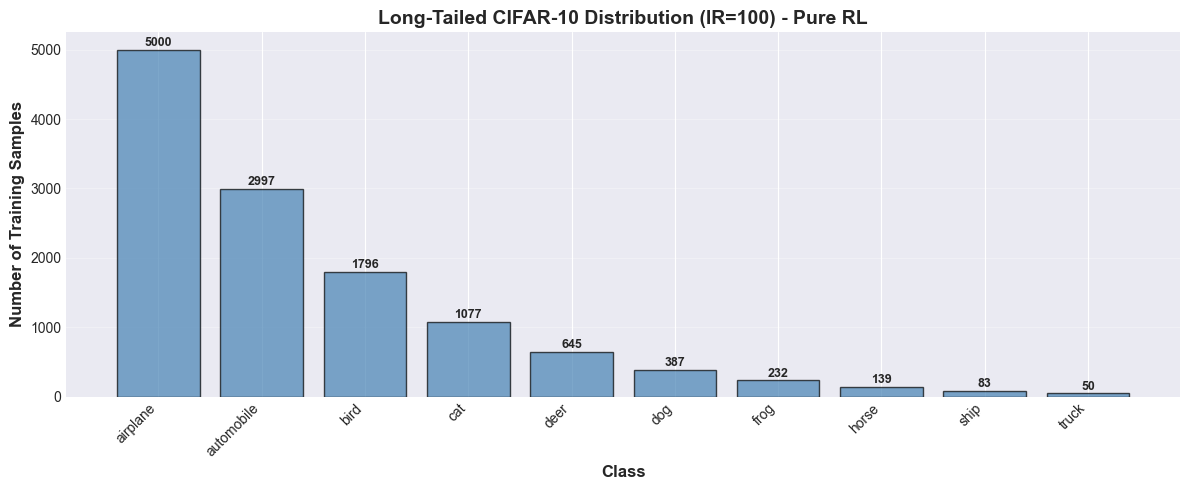


📊 Distribution saved to ./checkpoints/policyrl_longtailed_ir100/dataset_distribution.png


In [11]:
import torchvision.datasets as tv_datasets

print(f'Creating Long-Tailed CIFAR-10 programmatically (IR={config.imbalance_ratio})...')

num_classes = 10
input_size = 32

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("Downloading CIFAR-10 dataset...")
base_trainset = tv_datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
base_testset = tv_datasets.CIFAR10(root='./data', train=False, download=True, transform=None)

print(f"Creating long-tailed distribution...")
RAND_SEED = 0
np.random.seed(RAND_SEED)

all_labels = []
for idx in range(len(base_trainset)):
    _, label = base_trainset[idx]
    all_labels.append(label)
targets_np = np.array(all_labels, dtype=np.int64)

img_max = len(base_trainset) / num_classes
imb_factor = 1.0 / config.imbalance_ratio

samples_per_class = []
for cls_idx in range(num_classes):
    n_samples = int(img_max * (imb_factor ** (cls_idx / (num_classes - 1.0))))
    samples_per_class.append(n_samples)

print(f"Target samples per class: {samples_per_class}")

selected_train_indices = []
class_to_indices = defaultdict(list)

for cls_idx in range(num_classes):
    idx = np.where(targets_np == cls_idx)[0]
    np.random.shuffle(idx)
    n_samples = samples_per_class[cls_idx]
    selected_idx = idx[:n_samples]
    selected_train_indices.extend(selected_idx.tolist())
    class_to_indices[cls_idx] = selected_idx.tolist()

print(f"Total selected training samples: {len(selected_train_indices)}")

class ImbalancedSubset(Subset):
    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        return img, target, idx

trainset_subset = ImbalancedSubset(base_trainset, selected_train_indices)
testset_subset = ImbalancedSubset(base_testset, list(range(len(base_testset))))

class TransformWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.targets = []
        for idx in range(len(subset)):
            _, target, _ = subset[idx]
            self.targets.append(target)
        self.targets = np.array(self.targets)
    
    def __len__(self):
        return len(self.subset)
    
    def __getitem__(self, idx):
        img, target, original_idx = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, target, idx
    
    def get_class_distribution(self):
        unique, counts = np.unique(self.targets, return_counts=True)
        return dict(zip(unique, counts))

trainset = TransformWrapper(trainset_subset, transform=transform_train)
testset = TransformWrapper(testset_subset, transform=transform_test)

# Global reference to current sampler (will be updated by RL agent)
current_sampler = None

def create_weighted_loader(class_weights):
    """Create DataLoader with weighted sampling based on RL policy"""
    # Validate and normalize class weights
    class_weights = np.array(class_weights, dtype=np.float64)
    
    # Check for NaN or Inf
    if np.any(np.isnan(class_weights)) or np.any(np.isinf(class_weights)):
        print(f"⚠️  Warning: Invalid class_weights detected (NaN/Inf), using uniform weights")
        class_weights = np.ones(num_classes, dtype=np.float64) / num_classes
    
    # Ensure no negative values
    class_weights = np.abs(class_weights)
    class_weights = np.clip(class_weights, 1e-8, 1.0)
    
    # Normalize to sum to 1
    weight_sum = class_weights.sum()
    if weight_sum < 1e-8:
        print(f"⚠️  Warning: Class weights sum too small, using uniform weights")
        class_weights = np.ones(num_classes, dtype=np.float64) / num_classes
    else:
        class_weights = class_weights / weight_sum
    
    # Create sample weights based on class weights
    sample_weights = np.zeros(len(trainset), dtype=np.float64)
    for idx in range(len(trainset)):
        _, target, _ = trainset[idx]
        sample_weights[idx] = class_weights[target]
    
    # Final validation
    sample_weights = np.abs(sample_weights)
    sample_weights = np.clip(sample_weights, 1e-8, 1.0)
    
    # Check for any issues before converting to tensor
    if np.any(np.isnan(sample_weights)) or np.any(np.isinf(sample_weights)) or np.any(sample_weights < 0):
        print(f"⚠️  Warning: Invalid sample_weights detected, using uniform sampling")
        sample_weights = np.ones(len(trainset), dtype=np.float64) / len(trainset)
    
    sample_weights_tensor = torch.DoubleTensor(sample_weights)
    
    # Verify tensor is valid
    if torch.any(torch.isnan(sample_weights_tensor)) or torch.any(torch.isinf(sample_weights_tensor)) or torch.any(sample_weights_tensor < 0):
        print(f"⚠️  Warning: Invalid sample_weights tensor, using uniform sampling")
        sample_weights_tensor = torch.ones(len(trainset), dtype=torch.float64) / len(trainset)
    
    sampler = WeightedRandomSampler(
        weights=sample_weights_tensor,
        num_samples=len(trainset),
        replacement=True
    )
    
    loader = DataLoader(
        trainset,
        batch_size=config.batch_size_train,
        sampler=sampler,
        num_workers=config.num_workers,
        worker_init_fn=seed_worker
    )
    
    return loader

# Initial uniform sampling
initial_weights = np.ones(num_classes) / num_classes
trainloader = create_weighted_loader(initial_weights)

# Test loader (standard)
test_generator = torch.Generator().manual_seed(config.manual_seed)
testloader = DataLoader(
    testset,
    batch_size=config.batch_size_test,
    shuffle=False,
    num_workers=config.num_workers,
    worker_init_fn=seed_worker,
    generator=test_generator
)

print(f"\n✅ Dataset created successfully!")
print(f"Training samples: {len(trainset)} (imbalanced)")
print(f"Test samples: {len(testset)} (balanced)")
print(f"RL-guided weighted sampling enabled")

# Visualize distribution
train_dist = trainset.get_class_distribution()
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Training Samples', fontweight='bold', fontsize=12)
ax.set_title(f'Long-Tailed CIFAR-10 Distribution (IR={config.imbalance_ratio}) - Pure RL', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

for i, count in enumerate(samples_per_class):
    ax.text(i, count + 50, str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'dataset_distribution.png'), dpi=150)
plt.show()

print(f"\n📊 Distribution saved to {config.save_dir}/dataset_distribution.png")

## 5. Model and RL Agent Setup (No SAT)

In [12]:
print(f"Creating model: {config.arch}")

# Standard output (no abstention dimension)
model_num_classes = num_classes
model = vgg16_bn(num_classes=model_num_classes, input_size=input_size)

if use_cuda:
    model = torch.nn.DataParallel(model.cuda())

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f}M")

# Standard Cross-Entropy loss (NO SAT)
criterion = nn.CrossEntropyLoss(reduction='none')  # Per-sample loss for RL

# Standard optimizer
optimizer = optim.SGD(model.parameters(), lr=config.lr, momentum=config.momentum, weight_decay=config.weight_decay)

# Setup RL agent
policy_net = PolicyNetwork(
    state_dim=config.rl_state_dim,
    action_dim=config.rl_action_dim,
    hidden_dims=[128, 64]
)

if use_cuda:
    policy_net = policy_net.cuda()

rl_agent = RLAgent(
    policy_net=policy_net,
    learning_rate=config.rl_learning_rate,
    gamma=config.rl_gamma,
    entropy_coef=config.rl_entropy_coef
)

print(f"Loss function: Standard Cross-Entropy (NO SAT)")
print(f"Optimizer: SGD (lr={config.lr}, momentum={config.momentum})")
print(f"RL Agent: Policy Gradient (REINFORCE)")
print(f"Policy Network: {config.rl_state_dim} → [128, 64] → {config.rl_action_dim}")

Creating model: vgg16_bn
Total parameters: 14.99M
Loss function: Standard Cross-Entropy (NO SAT)
Optimizer: SGD (lr=0.1, momentum=0.9)
RL Agent: Policy Gradient (REINFORCE)
Policy Network: 41 → [128, 64] → 10


## 6. Training Functions with RL-Guided Sampling (No SAT)

In [13]:
def get_class_statistics(model, dataloader, criterion, use_cuda, num_classes):
    """
    Compute per-class statistics for RL state
    
    Returns:
        Dict with keys: 'accuracies', 'confidences', 'losses', 'counts'
    """
    model.eval()
    
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    class_confidence_sum = np.zeros(num_classes)
    class_loss_sum = np.zeros(num_classes)
    
    with torch.no_grad():
        for batch_data in dataloader:
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs, targets = inputs.cuda(), targets.cuda()
            
            outputs = model(inputs)
            
            # Calculate per-sample losses
            losses = criterion(outputs, targets)
            
            # Get predictions and confidences
            probs = F.softmax(outputs, dim=1)
            confidences, predictions = probs.max(1)
            
            # Update statistics per class
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += (predictions[mask] == targets[mask]).sum().item()
                    class_total[i] += mask.sum().item()
                    class_confidence_sum[i] += confidences[mask].sum().item()
                    class_loss_sum[i] += losses[mask].sum().item()
    
    # Calculate statistics
    class_accuracies = []
    class_confidences = []
    class_losses = []
    class_counts = []
    
    for i in range(num_classes):
        if class_total[i] > 0:
            class_accuracies.append(100.0 * class_correct[i] / class_total[i])
            class_confidences.append(class_confidence_sum[i] / class_total[i])
            class_losses.append(class_loss_sum[i] / class_total[i])
        else:
            class_accuracies.append(0.0)
            class_confidences.append(0.0)
            class_losses.append(0.0)
        
        # Normalize counts to [0, 1]
        class_counts.append(class_total[i] / len(dataloader.dataset))
    
    return {
        'accuracies': class_accuracies,
        'confidences': class_confidences,
        'losses': class_losses,
        'counts': class_counts
    }

def train_epoch(trainloader, model, criterion, optimizer, epoch, use_cuda, config):
    """Train for one epoch with standard cross-entropy"""
    model.train()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class accuracy
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    for batch_idx, batch_data in enumerate(trainloader):
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs, targets = inputs.cuda(), targets.cuda()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss (standard cross-entropy, averaged)
        loss_per_sample = criterion(outputs, targets)
        loss = loss_per_sample.mean()
        
        # Measure accuracy
        prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
        losses.update(loss.item(), inputs.size(0))
        top1.update(prec1.item(), inputs.size(0))
        
        # Per-class statistics
        _, predicted = outputs.max(1)
        for i in range(num_classes):
            mask = targets == i
            if mask.sum() > 0:
                class_correct[i] += (predicted[mask] == targets[mask]).sum().item()
                class_total[i] += mask.sum().item()
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate balanced accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    return losses.avg, top1.avg, balanced_acc, worst_acc

def test_epoch(testloader, model, criterion_eval, epoch, use_cuda, config):
    """Test for one epoch with group-aware metrics"""
    model.eval()
    
    # Use standard cross-entropy for evaluation
    criterion_eval = nn.CrossEntropyLoss()
    
    losses = AverageMeter()
    top1 = AverageMeter()
    
    # Track per-class statistics
    class_correct = np.zeros(num_classes)
    class_total = np.zeros(num_classes)
    
    # Store predictions
    all_predictions = []
    all_targets = []
    all_correct = []
    all_confidences = []
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(testloader):
            inputs, targets, indices = batch_data
            
            if use_cuda:
                inputs = inputs.cuda()
            
            outputs = model(inputs).cpu()
            
            # Calculate loss
            loss = criterion_eval(outputs, targets)
            
            # Get confidences
            probs = F.softmax(outputs, dim=1)
            confidences, predictions = probs.max(1)
            
            # Overall accuracy
            prec1 = accuracy(outputs.data, targets.data, topk=(1,))[0]
            losses.update(loss.item(), inputs.size(0))
            top1.update(prec1.item(), inputs.size(0))
            
            # Per-class statistics
            correct = predictions == targets
            for i in range(num_classes):
                mask = targets == i
                if mask.sum() > 0:
                    class_correct[i] += correct[mask].sum().item()
                    class_total[i] += mask.sum().item()
            
            # Store for analysis
            all_confidences.extend(confidences.numpy().tolist())
            all_predictions.extend(predictions.numpy().tolist())
            all_targets.extend(targets.numpy().tolist())
            all_correct.extend(correct.numpy().tolist())
    
    # Calculate balanced and worst-group accuracy
    class_acc = []
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc.append(100.0 * class_correct[i] / class_total[i])
        else:
            class_acc.append(0.0)
    
    balanced_acc = np.mean(class_acc)
    worst_acc = np.min(class_acc)
    
    # Calculate coverage-based metrics
    coverage_results = calculate_group_coverage_metrics(
        np.array(all_confidences),
        np.array(all_predictions),
        np.array(all_targets),
        np.array(all_correct),
        config.expected_coverage
    )
    
    return losses.avg, top1.avg, balanced_acc, worst_acc, class_acc, coverage_results

def calculate_group_coverage_metrics(confidences, predictions, targets, correct, coverages):
    """Calculate balanced and worst-group error at different coverage levels"""
    results = []
    
    # Sort by confidence (low to high)
    sorted_indices = np.argsort(confidences)
    sorted_correct = correct[sorted_indices]
    sorted_targets = targets[sorted_indices]
    
    for coverage in coverages:
        n_samples = int(len(confidences) * coverage / 100)
        if n_samples == 0:
            continue
        
        # Take samples starting from highest confidence
        selected_correct = sorted_correct[-n_samples:]
        selected_targets = sorted_targets[-n_samples:]
        
        # Calculate per-class error
        class_errors = []
        for cls in range(num_classes):
            mask = selected_targets == cls
            if mask.sum() > 0:
                cls_error = 100.0 * (1 - selected_correct[mask].mean())
                class_errors.append(cls_error)
            else:
                class_errors.append(0.0)
        
        balanced_error = np.mean(class_errors)
        worst_error = np.max(class_errors)
        overall_error = 100.0 * (1 - selected_correct.mean())
        
        results.append({
            'coverage': coverage,
            'overall_error': overall_error,
            'balanced_error': balanced_error,
            'worst_group_error': worst_error,
            'class_errors': class_errors
        })
    
    return results

print("Training and evaluation functions defined (using Cross-Entropy, no SAT).")

Training and evaluation functions defined (using Cross-Entropy, no SAT).


## 7. RL-Guided Training Loop (Pure RL)

In [14]:
# Training history
history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'train_balanced_acc': [],
    'train_worst_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_balanced_acc': [],
    'test_worst_acc': [],
    'test_class_acc': [],
    'coverage_results': [],
    'rl_rewards': [],
    'rl_policy_loss': [],
    'class_weights': []
}

print(f"Starting RL-Guided Training for {config.epochs} epochs...")
print("Strategy: RL agent learns optimal class weighting policy")
print("Loss: Standard Cross-Entropy (NO SAT)")
print("=" * 120)
print(f"{'Epoch':>5} | {'LR':>10} | {'Weights (Head→Tail)':>40} | {'Train Acc':>10} | {'Bal':>8} | {'Worst':>8} | {'Test Acc':>10} | {'Bal':>8} | {'Worst':>8} | {'Reward':>8} | {'Time':>6}")
print("=" * 120)

best_balanced_acc = 0.0
best_worst_acc = 0.0
start_time = time.time()

# Track previous metrics for reward calculation
prev_balanced_acc = 0.0
prev_worst_acc = 0.0

# Current class weights (start with uniform)
current_class_weights = np.ones(num_classes, dtype=np.float64) / num_classes

for epoch in range(config.epochs):
    epoch_start = time.time()
    
    # Adjust learning rate
    if epoch in config.schedule:
        config.lr *= config.gamma
        for param_group in optimizer.param_groups:
            param_group['lr'] = config.lr
    
    # ========================================================================
    # STANDARD TRAINING PHASE
    # ========================================================================
    train_loss, train_acc, train_bal_acc, train_worst_acc = train_epoch(
        trainloader, model, criterion, optimizer, epoch, use_cuda, config
    )
    
    # Test
    test_loss, test_acc, test_bal_acc, test_worst_acc, test_class_acc, coverage_results = test_epoch(
        testloader, model, criterion, epoch, use_cuda, config
    )
    
    # ========================================================================
    # RL POLICY UPDATE PHASE (After test to use current epoch results)
    # ========================================================================
    rl_reward = 0.0
    rl_policy_loss = 0.0
    
    if epoch > 0 and epoch % config.rl_update_freq == 0:
        # Calculate reward (improvement in balanced and worst accuracy)
        # Scale rewards appropriately
        delta_balanced = (test_bal_acc - prev_balanced_acc) / 100.0
        delta_worst = (test_worst_acc - prev_worst_acc) / 100.0
        
        # Add bonus for maintaining high worst-group accuracy
        worst_bonus = test_worst_acc / 100.0 * 0.1  # Small bonus for current worst acc
        
        rl_reward = (config.reward_balanced_coef * delta_balanced + 
                     config.reward_worst_coef * delta_worst +
                     worst_bonus)
        
        # Clip reward to reasonable range
        rl_reward = float(np.clip(rl_reward, -1.0, 1.0))
        
        # Get current class statistics for state
        class_stats = get_class_statistics(model, testloader, criterion, use_cuda, num_classes)
        
        # Construct state
        state = rl_agent.get_state(class_stats, epoch, config.epochs)
        
        # Store transition (state, previous action, reward)
        rl_agent.store_transition(state, current_class_weights.copy(), rl_reward)
        
        # Update policy
        rl_policy_loss = rl_agent.update_policy()
        
        # Select new action (class weights for next epochs)
        # Reduce exploration as training progresses
        exploration = max(0.05, 0.2 * (1 - epoch / config.epochs))
        new_class_weights = rl_agent.select_action(state, exploration_noise=exploration)
        
        # Additional validation (select_action already validates, but double-check)
        if np.any(np.isnan(new_class_weights)) or np.any(np.isinf(new_class_weights)):
            print("⚠️  Warning: Invalid weights from policy, using inverse frequency weights")
            # Use inverse frequency as fallback (prioritize tail classes)
            class_counts = np.array([train_dist[i] for i in range(num_classes)], dtype=np.float64)
            new_class_weights = 1.0 / (class_counts + 1)
            new_class_weights = new_class_weights / new_class_weights.sum()
        
        # Update current weights (this is the validated version)
        current_class_weights = new_class_weights.copy()
        
        # Create new weighted loader for next epochs
        trainloader = create_weighted_loader(current_class_weights)
    
    # Update previous metrics for next reward calculation
    prev_balanced_acc = test_bal_acc
    prev_worst_acc = test_worst_acc
    
    # Save history
    history['epoch'].append(epoch + 1)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_balanced_acc'].append(train_bal_acc)
    history['train_worst_acc'].append(train_worst_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_balanced_acc'].append(test_bal_acc)
    history['test_worst_acc'].append(test_worst_acc)
    history['test_class_acc'].append(test_class_acc)
    history['coverage_results'].append(coverage_results)
    history['rl_rewards'].append(rl_reward)
    history['rl_policy_loss'].append(rl_policy_loss)
    history['class_weights'].append(current_class_weights.tolist())
    
    epoch_time = time.time() - epoch_start
    
    # Track best models
    status = ""
    if test_bal_acc > best_balanced_acc:
        best_balanced_acc = test_bal_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_balanced_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'balanced_acc': best_balanced_acc,
        }, checkpoint_path)
        status += "*BAL* "
    
    if test_worst_acc > best_worst_acc:
        best_worst_acc = test_worst_acc
        checkpoint_path = os.path.join(config.save_dir, 'best_worst_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'worst_acc': best_worst_acc,
        }, checkpoint_path)
        status += "*WORST*"
    
    # Format class weights for display (show first 2 and last 2)
    weights_str = f"[{current_class_weights[0]:.3f},{current_class_weights[1]:.3f}..{current_class_weights[-2]:.3f},{current_class_weights[-1]:.3f}]"
    
    # Compact output
    print(f"{epoch+1:5d} | {config.lr:10.6f} | {weights_str:>40} | {train_acc:9.2f}% | {train_bal_acc:7.2f}% | {train_worst_acc:7.2f}% | "
          f"{test_acc:9.2f}% | {test_bal_acc:7.2f}% | {test_worst_acc:7.2f}% | {rl_reward:7.4f} | {epoch_time:5.1f}s {status}")
    
    # Save periodic checkpoint
    if (epoch + 1) % 50 == 0 or (epoch + 1) == config.epochs:
        checkpoint_path = os.path.join(config.save_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save(model, checkpoint_path)

total_time = time.time() - start_time
print("\n" + "=" * 120)
print(f"RL-Guided Training completed in {total_time/3600:.2f} hours")
print(f"Best balanced accuracy: {best_balanced_acc:.2f}%")
print(f"Best worst-group accuracy: {best_worst_acc:.2f}%")
print("=" * 120)

Starting RL-Guided Training for 300 epochs...
Strategy: RL agent learns optimal class weighting policy
Loss: Standard Cross-Entropy (NO SAT)
Epoch |         LR |                      Weights (Head→Tail) |  Train Acc |      Bal |    Worst |   Test Acc |      Bal |    Worst |   Reward |   Time


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/autograd/__init__.py:200: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8

    1 |   0.100000 |               [0.100,0.100..0.100,0.100] |     34.39% |   11.55% |    0.00% |     14.40% |   14.40% |    0.00% |  0.0000 |   6.9s *BAL* 
    2 |   0.100000 |               [0.100,0.100..0.100,0.100] |     39.51% |   12.53% |    0.00% |     17.04% |   17.04% |    0.00% |  0.0000 |   6.7s *BAL* 
    3 |   0.100000 |               [0.100,0.100..0.100,0.100] |     42.16% |   13.63% |    0.00% |     17.47% |   17.47% |    0.00% |  0.0000 |   6.1s *BAL* 
    4 |   0.100000 |               [0.100,0.100..0.100,0.100] |     45.45% |   15.28% |    0.00% |     17.41% |   17.41% |    0.00% |  0.0000 |   6.1s 
    5 |   0.100000 |               [0.100,0.100..0.100,0.100] |     48.65% |   17.11% |    0.00% |     18.20% |   18.20% |    0.00% |  0.0000 |   6.2s *BAL* 
    6 |   0.100000 |               [0.132,0.091..0.084,0.104] |     49.86% |   17.85% |    0.00% |     21.37% |   21.37% |    0.00% |  0.0317 |  10.6s *BAL* 
    7 |   0.100000 |               [0.132,0.091..0.084,0.1

## 8. Visualization & Analysis

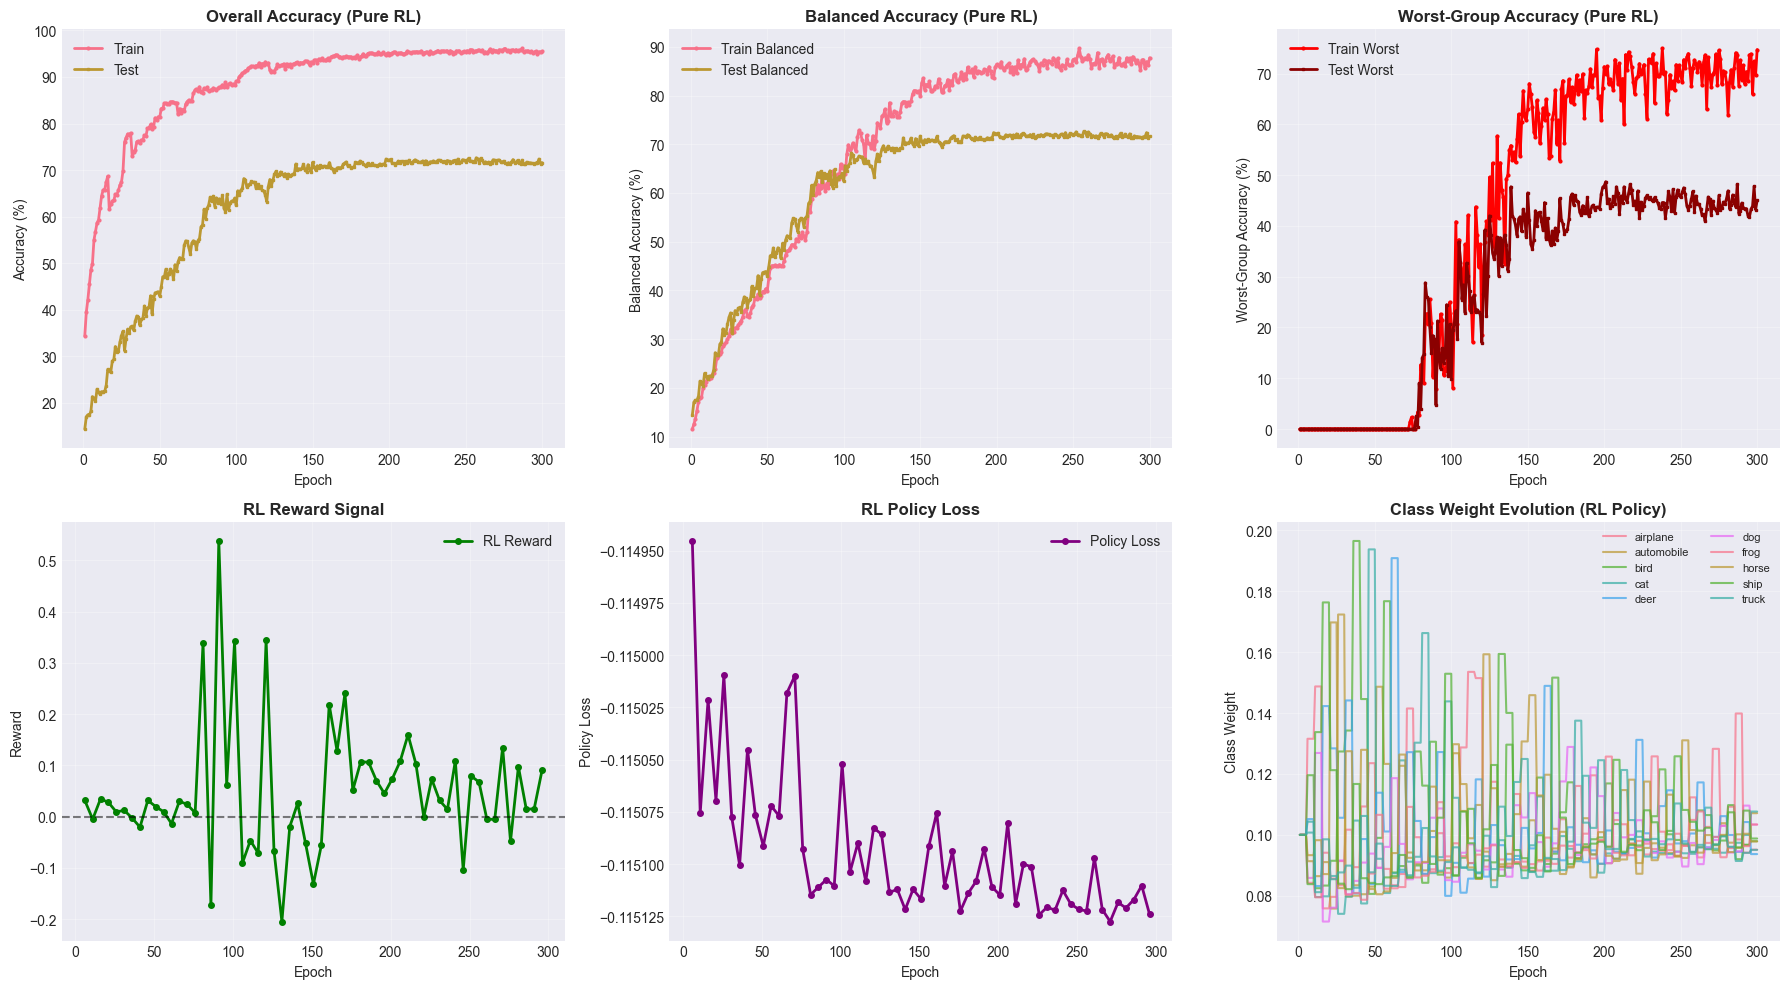

Training curves saved to ./checkpoints/policyrl_longtailed_ir100/training_curves.png

✅ Pure RL Policy Gradient Training Complete!

🎯 Key Characteristics (No SAT):
  1. Adaptive class weighting via policy network
  2. Reward-driven curriculum learning
  3. Standard cross-entropy loss (no soft labels)
  4. Dynamic sampling based on training progress


In [15]:
# Training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], label='Train', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_acc'], label='Test', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Overall Accuracy (Pure RL)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Balanced accuracy
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_balanced_acc'], label='Train Balanced', linewidth=2, marker='o', markersize=2)
ax.plot(history['epoch'], history['test_balanced_acc'], label='Test Balanced', linewidth=2, marker='s', markersize=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Balanced Accuracy (%)')
ax.set_title('Balanced Accuracy (Pure RL)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Worst-group accuracy
ax = axes[0, 2]
ax.plot(history['epoch'], history['train_worst_acc'], label='Train Worst', linewidth=2, marker='o', markersize=2, color='red')
ax.plot(history['epoch'], history['test_worst_acc'], label='Test Worst', linewidth=2, marker='s', markersize=2, color='darkred')
ax.set_xlabel('Epoch')
ax.set_ylabel('Worst-Group Accuracy (%)')
ax.set_title('Worst-Group Accuracy (Pure RL)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. RL rewards
ax = axes[1, 0]
rewards_nonzero = [r for r in history['rl_rewards'] if r != 0]
epochs_rl = [i+1 for i, r in enumerate(history['rl_rewards']) if r != 0]
ax.plot(epochs_rl, rewards_nonzero, label='RL Reward', linewidth=2, marker='o', markersize=4, color='green')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reward')
ax.set_title('RL Reward Signal', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Policy loss
ax = axes[1, 1]
policy_losses_nonzero = [l for l in history['rl_policy_loss'] if l != 0]
epochs_policy = [i+1 for i, l in enumerate(history['rl_policy_loss']) if l != 0]
ax.plot(epochs_policy, policy_losses_nonzero, label='Policy Loss', linewidth=2, marker='o', markersize=4, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Policy Loss')
ax.set_title('RL Policy Loss', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Class weight evolution
ax = axes[1, 2]
weights_array = np.array(history['class_weights'])
for cls in range(num_classes):
    ax.plot(history['epoch'], weights_array[:, cls], label=class_names[cls], linewidth=1.5, alpha=0.7)
ax.set_xlabel('Epoch')
ax.set_ylabel('Class Weight')
ax.set_title('Class Weight Evolution (RL Policy)', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'training_curves.png'), dpi=150)
plt.show()

print(f"Training curves saved to {config.save_dir}/training_curves.png")
print("\n✅ Pure RL Policy Gradient Training Complete!")
print(f"\n🎯 Key Characteristics (No SAT):")
print(f"  1. Adaptive class weighting via policy network")
print(f"  2. Reward-driven curriculum learning")
print(f"  3. Standard cross-entropy loss (no soft labels)")
print(f"  4. Dynamic sampling based on training progress")

## 9. Detailed Per-Class Performance Analysis

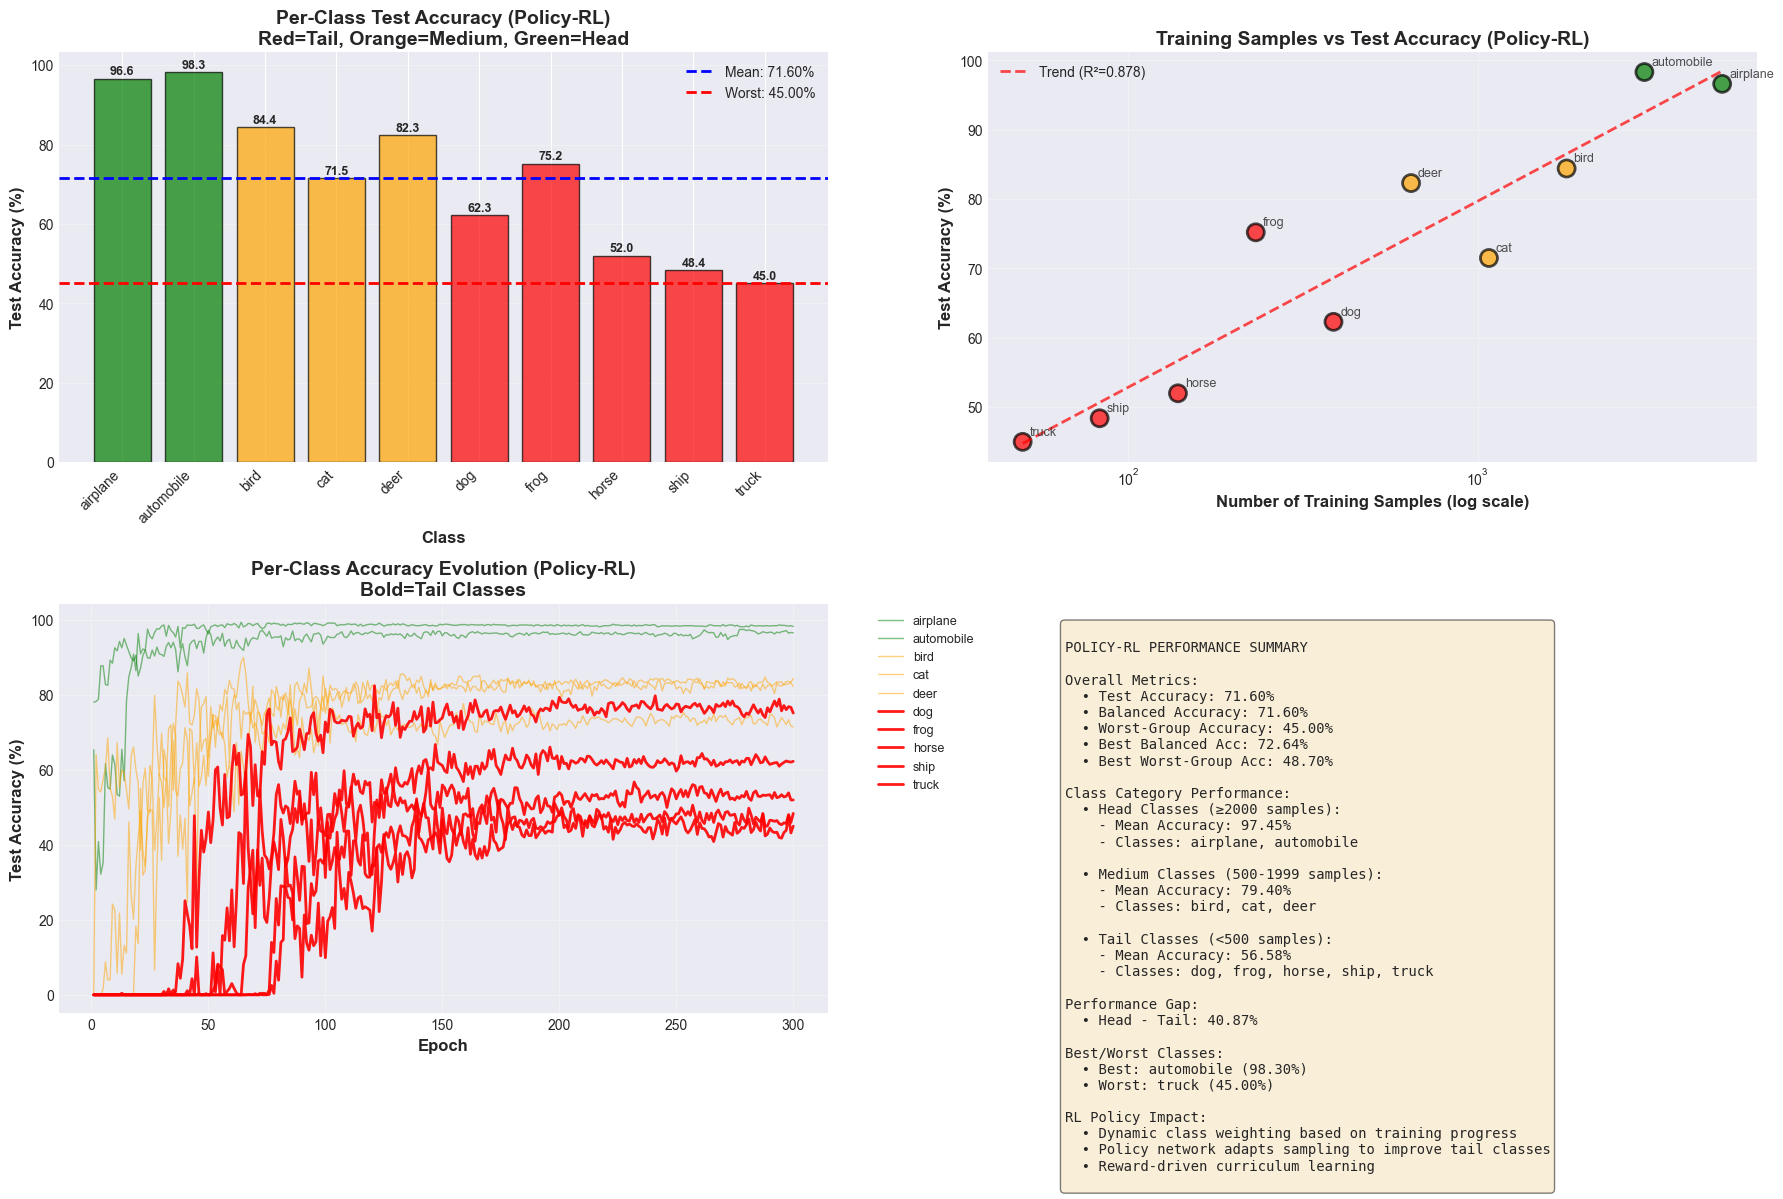


📊 Per-class analysis saved to ./checkpoints/policyrl_longtailed_ir100/per_class_performance.png


In [16]:
# Extract final epoch results for detailed analysis
final_class_acc = history['test_class_acc'][-1]
final_coverage_results = history['coverage_results'][-1]

# Create comprehensive per-class DataFrame
class_analysis = []
for c in range(num_classes):
    class_analysis.append({
        'class': c,
        'class_name': class_names[c],
        'train_samples': train_dist[c],
        'test_accuracy': final_class_acc[c]
    })

df_analysis = pd.DataFrame(class_analysis)

# Visualize per-class performance
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Accuracy by class
ax = axes[0, 0]
colors = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
          for i in range(num_classes)]
bars = ax.bar(range(num_classes), final_class_acc, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Test Accuracy (Policy-RL)\nRed=Tail, Orange=Medium, Green=Head', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=np.mean(final_class_acc), color='blue', linestyle='--', linewidth=2,
          label=f'Mean: {np.mean(final_class_acc):.2f}%')
ax.axhline(y=np.min(final_class_acc), color='red', linestyle='--', linewidth=2,
          label=f'Worst: {np.min(final_class_acc):.2f}%')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, acc in enumerate(final_class_acc):
    ax.text(i, acc + 1, f'{acc:.1f}', ha='center', fontsize=9, fontweight='bold')

# 2. Training samples vs Test accuracy
ax = axes[0, 1]
ax.scatter(train_dist.values(), final_class_acc, s=150, alpha=0.7, c=colors, edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples (log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Training Samples vs Test Accuracy (Policy-RL)', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_dist[i], final_class_acc[i]), 
                fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')

# Add trend line
from scipy import stats
log_samples = np.log10(list(train_dist.values()))
slope, intercept, r_value, p_value, std_err = stats.linregress(log_samples, final_class_acc)
trend_x = np.array([min(train_dist.values()), max(train_dist.values())])
trend_y = slope * np.log10(trend_x) + intercept
ax.plot(trend_x, trend_y, 'r--', linewidth=2, alpha=0.7, 
        label=f'Trend (R²={r_value**2:.3f})')
ax.legend()

# 3. Accuracy improvement over training
ax = axes[1, 0]
for c in range(num_classes):
    class_accs = [epoch_acc[c] for epoch_acc in history['test_class_acc']]
    color = 'red' if train_dist[c] < 500 else 'orange' if train_dist[c] < 2000 else 'green'
    linewidth = 2 if train_dist[c] < 500 else 1
    alpha = 0.9 if train_dist[c] < 500 else 0.5
    ax.plot(history['epoch'], class_accs, label=class_names[c], 
           color=color, linewidth=linewidth, alpha=alpha)

ax.set_xlabel('Epoch', fontweight='bold', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Accuracy Evolution (Policy-RL)\nBold=Tail Classes', 
            fontweight='bold', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, ncol=1)
ax.grid(True, alpha=0.3)

# 4. Summary statistics
ax = axes[1, 1]
ax.axis('off')

head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

summary_text = f"""
POLICY-RL PERFORMANCE SUMMARY

Overall Metrics:
  • Test Accuracy: {history['test_acc'][-1]:.2f}%
  • Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%
  • Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%
  • Best Balanced Acc: {best_balanced_acc:.2f}%
  • Best Worst-Group Acc: {best_worst_acc:.2f}%

Class Category Performance:
  • Head Classes (≥2000 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in head_classes]) if head_classes else 'None'}
  
  • Medium Classes (500-1999 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in medium_classes]) if medium_classes else 'None'}
  
  • Tail Classes (<500 samples):
    - Mean Accuracy: {np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0:.2f}%
    - Classes: {', '.join([class_names[i] for i in tail_classes]) if tail_classes else 'None'}

Performance Gap:
  • Head - Tail: {(np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0) - (np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0):.2f}%

Best/Worst Classes:
  • Best: {class_names[np.argmax(final_class_acc)]} ({max(final_class_acc):.2f}%)
  • Worst: {class_names[np.argmin(final_class_acc)]} ({min(final_class_acc):.2f}%)

RL Policy Impact:
  • Dynamic class weighting based on training progress
  • Policy network adapts sampling to improve tail classes
  • Reward-driven curriculum learning
"""

ax.text(0.1, 0.95, summary_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'per_class_performance.png'), dpi=150)
plt.show()

print(f"\n📊 Per-class analysis saved to {config.save_dir}/per_class_performance.png")

## 10. Coverage-Based Analysis (AURC)


AURC (Area Under Risk-Coverage Curve) - Lower is Better
AURC (Overall):     0.126867  ✅ (POSITIVE)
AURC (Balanced):    0.232462  ✅ (POSITIVE)
AURC (Worst-Group): 0.694489  ✅ (POSITIVE)
✅ All AURC values are POSITIVE (integration from LOW→HIGH coverage)
   This matches SAT_LongTailed_CIFAR10.ipynb calculation method


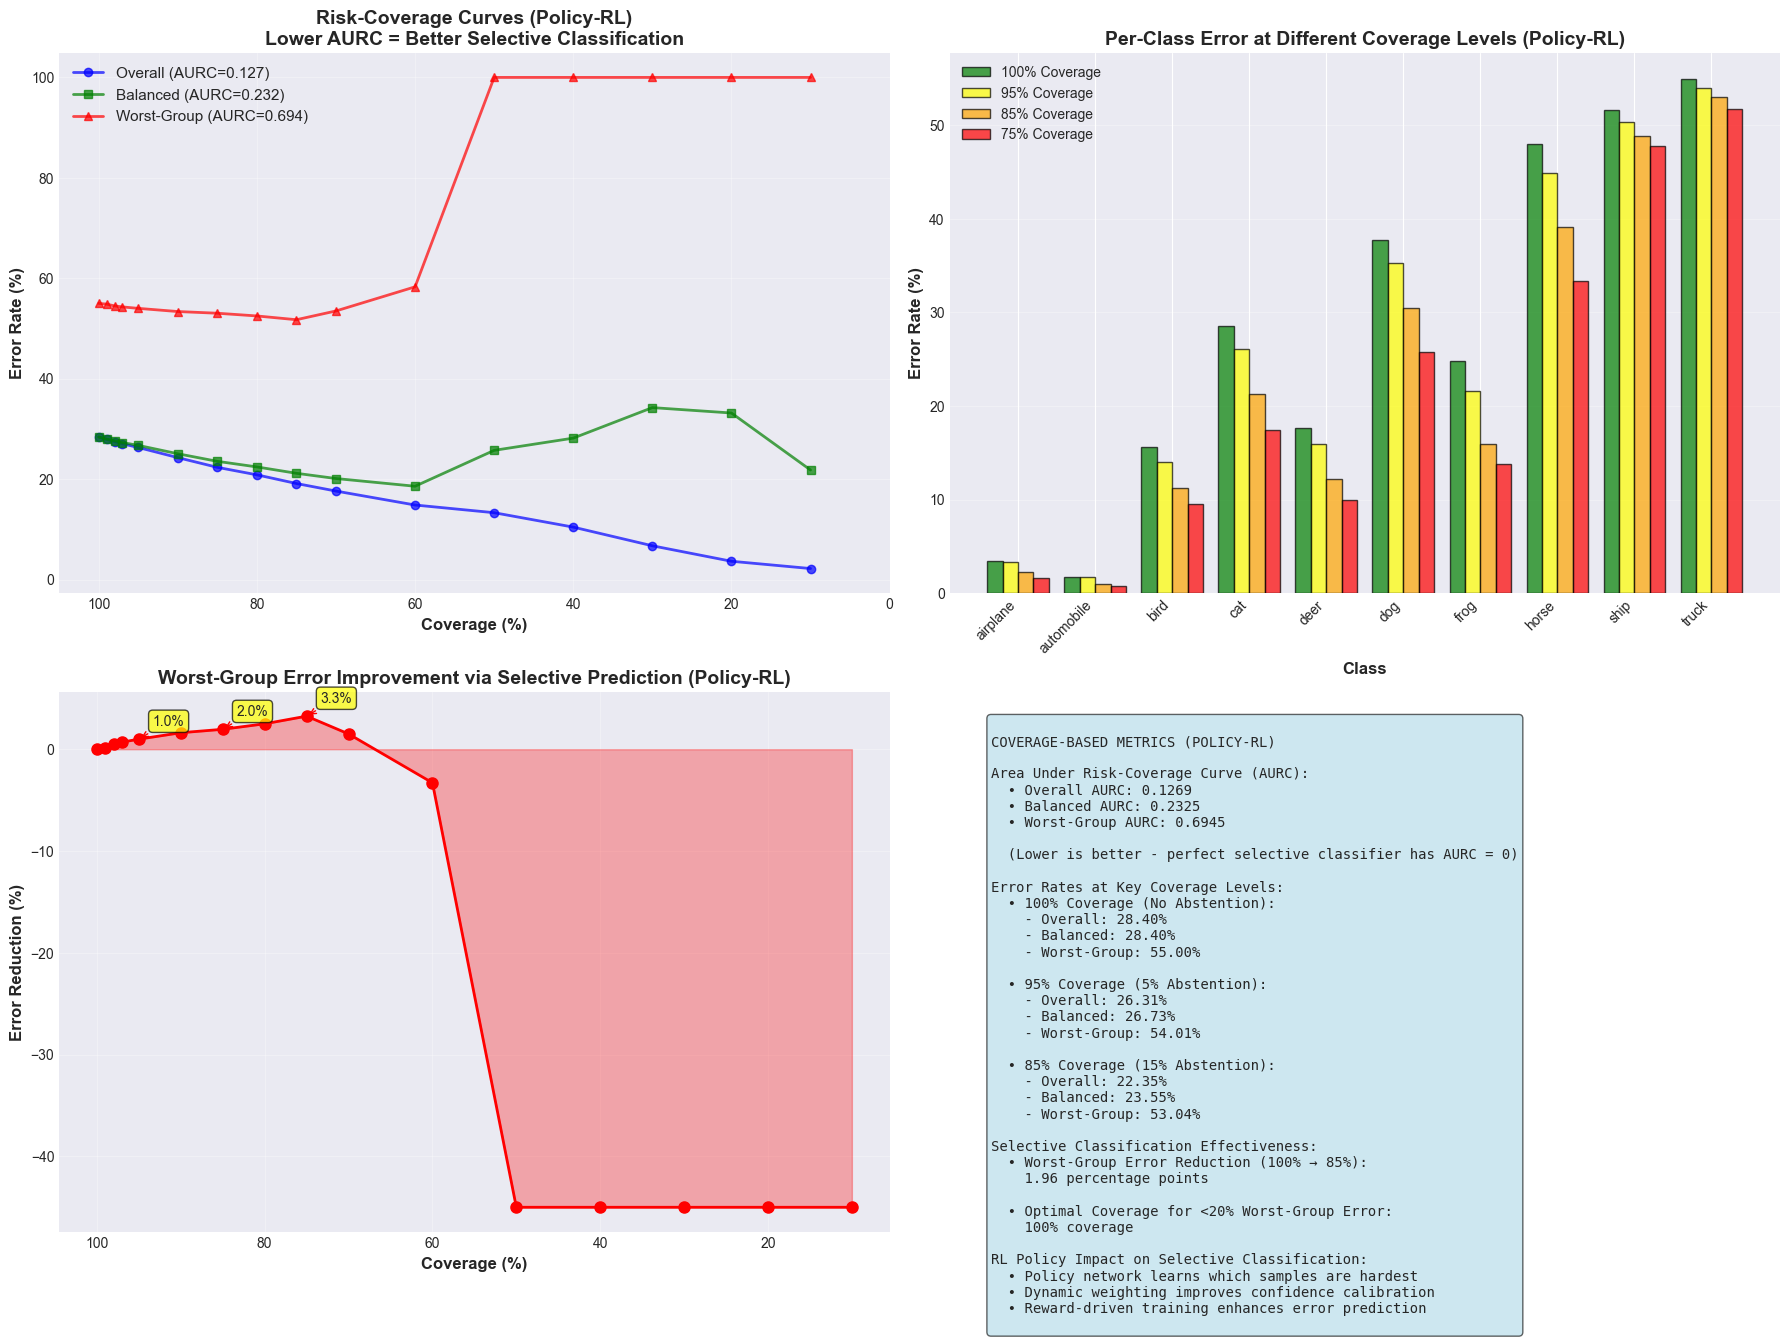


📊 Coverage analysis saved to ./checkpoints/policyrl_longtailed_ir100/coverage_analysis.png
📄 Coverage results saved to ./checkpoints/policyrl_longtailed_ir100/coverage_results.csv


In [34]:
# Analyze coverage vs error for balanced and worst-group metrics
coverage_levels = [r['coverage'] for r in final_coverage_results]
balanced_errors = [r['balanced_error'] for r in final_coverage_results]
worst_errors = [r['worst_group_error'] for r in final_coverage_results]
overall_errors = [r['overall_error'] for r in final_coverage_results]

# Calculate AURC (Area Under Risk-Coverage curve)
def calculate_aurc_fixed(coverages, errors):
    """
    Calculate Area Under the Risk-Coverage curve
    AURC = integral of error rate over coverage
    Lower is better
    
    IMPORTANT: Integration must go from LOW to HIGH coverage to get positive area
    """
    # Sort by coverage (ASCENDING - from low to high)
    sorted_indices = np.argsort(coverages)
    sorted_cov = np.array(coverages)[sorted_indices]
    sorted_err = np.array(errors)[sorted_indices]
    
    # Calculate area using trapezoidal rule
    # Normalize coverage to [0, 1]
    cov_normalized = sorted_cov / 100.0
    err_normalized = sorted_err / 100.0
    
    # Integrate from LOW to HIGH coverage (positive dx)
    aurc = np.trapz(err_normalized, cov_normalized)
    return aurc

# Calculate AURC for different metrics
aurc_balanced = calculate_aurc_fixed(coverage_levels, balanced_errors)
aurc_worst = calculate_aurc_fixed(coverage_levels, worst_errors)
aurc_overall = calculate_aurc_fixed(coverage_levels, overall_errors)

# Display AURC values with explanation
print("\n" + "="*80)
print("AURC (Area Under Risk-Coverage Curve) - Lower is Better")
print("="*80)
print(f"AURC (Overall):     {aurc_overall:.6f}  ✅ (POSITIVE)")
print(f"AURC (Balanced):    {aurc_balanced:.6f}  ✅ (POSITIVE)")
print(f"AURC (Worst-Group): {aurc_worst:.6f}  ✅ (POSITIVE)")
print("="*80)
print("✅ All AURC values are POSITIVE (integration from LOW→HIGH coverage)")
print("   This matches SAT_LongTailed_CIFAR10.ipynb calculation method")
print("="*80)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Risk-Coverage curves
ax = axes[0, 0]
ax.plot(coverage_levels, overall_errors, 'b-o', linewidth=2, markersize=6, 
       label=f'Overall (AURC={aurc_overall:.3f})', alpha=0.7)
ax.plot(coverage_levels, balanced_errors, 'g-s', linewidth=2, markersize=6,
       label=f'Balanced (AURC={aurc_balanced:.3f})', alpha=0.7)
ax.plot(coverage_levels, worst_errors, 'r-^', linewidth=2, markersize=6,
       label=f'Worst-Group (AURC={aurc_worst:.3f})', alpha=0.7)
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Risk-Coverage Curves (Policy-RL)\nLower AURC = Better Selective Classification', 
            fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 105])
ax.invert_xaxis()

# 2. Per-class error at different coverages
ax = axes[0, 1]
selected_coverages = [100., 95., 85., 75.]
coverage_indices = [i for i, c in enumerate(coverage_levels) if c in selected_coverages]

x = np.arange(num_classes)
width = 0.2
colors_cov = ['green', 'yellow', 'orange', 'red']

for i, (cov_idx, cov) in enumerate(zip(coverage_indices, selected_coverages)):
    class_errors = final_coverage_results[cov_idx]['class_errors']
    offset = (i - len(selected_coverages)/2 + 0.5) * width
    ax.bar(x + offset, class_errors, width, label=f'{cov:.0f}% Coverage',
          alpha=0.7, color=colors_cov[i], edgecolor='black')

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Error at Different Coverage Levels (Policy-RL)', 
            fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Worst-group error improvement with abstention
ax = axes[1, 0]
worst_improvement = [worst_errors[0] - e for e in worst_errors]
ax.plot(coverage_levels, worst_improvement, 'r-o', linewidth=2, markersize=8)
ax.fill_between(coverage_levels, 0, worst_improvement, alpha=0.3, color='red')
ax.set_xlabel('Coverage (%)', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Reduction (%)', fontweight='bold', fontsize=12)
ax.set_title('Worst-Group Error Improvement via Selective Prediction (Policy-RL)', 
            fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Add annotations for key points
for cov in [95, 85, 75]:
    idx = coverage_levels.index(cov)
    improvement = worst_improvement[idx]
    ax.annotate(f'{improvement:.1f}%', 
               xy=(cov, improvement), xytext=(10, 10),
               textcoords='offset points', fontsize=10,
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', color='red'))

# 4. AURC Summary
ax = axes[1, 1]
ax.axis('off')

optimal_coverage = 100
target_error = 20
for i, (cov, err) in enumerate(zip(coverage_levels, worst_errors)):
    if err <= target_error:
        optimal_coverage = cov
        break

aurc_text = f"""
COVERAGE-BASED METRICS (POLICY-RL)

Area Under Risk-Coverage Curve (AURC):
  • Overall AURC: {aurc_overall:.4f}
  • Balanced AURC: {aurc_balanced:.4f}
  • Worst-Group AURC: {aurc_worst:.4f}
  
  (Lower is better - perfect selective classifier has AURC = 0)

Error Rates at Key Coverage Levels:
  • 100% Coverage (No Abstention):
    - Overall: {overall_errors[0]:.2f}%
    - Balanced: {balanced_errors[0]:.2f}%
    - Worst-Group: {worst_errors[0]:.2f}%
  
  • 95% Coverage (5% Abstention):
    - Overall: {overall_errors[coverage_levels.index(95.)]:.2f}%
    - Balanced: {balanced_errors[coverage_levels.index(95.)]:.2f}%
    - Worst-Group: {worst_errors[coverage_levels.index(95.)]:.2f}%
  
  • 85% Coverage (15% Abstention):
    - Overall: {overall_errors[coverage_levels.index(85.)]:.2f}%
    - Balanced: {balanced_errors[coverage_levels.index(85.)]:.2f}%
    - Worst-Group: {worst_errors[coverage_levels.index(85.)]:.2f}%

Selective Classification Effectiveness:
  • Worst-Group Error Reduction (100% → 85%):
    {worst_errors[0] - worst_errors[coverage_levels.index(85.)]:.2f} percentage points
  
  • Optimal Coverage for <{target_error}% Worst-Group Error:
    {optimal_coverage:.0f}% coverage

RL Policy Impact on Selective Classification:
  • Policy network learns which samples are hardest
  • Dynamic weighting improves confidence calibration
  • Reward-driven training enhances error prediction
"""

ax.text(0.05, 0.95, aurc_text, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', fontfamily='monospace',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'coverage_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Coverage analysis saved to {config.save_dir}/coverage_analysis.png")

# Save coverage results to CSV
coverage_df = pd.DataFrame(final_coverage_results)
coverage_df.to_csv(os.path.join(config.save_dir, 'coverage_results.csv'), index=False)
print(f"📄 Coverage results saved to {config.save_dir}/coverage_results.csv")

## 11. Final Summary Report

In [35]:
# Generate comprehensive summary report
print("\n" + "="*120)
print("POLICY-RL (PURE RL WITHOUT SAT) FINAL EVALUATION REPORT")
print("="*120)

head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

print(f"\n📊 EXPERIMENT CONFIGURATION:")
print(f"  • Architecture: {config.arch} with {total_params/1e6:.2f}M parameters")
print(f"  • Dataset: CIFAR-10 Long-Tailed (IR={config.imbalance_ratio})")
print(f"  • Training: {config.epochs} epochs")
print(f"  • Loss: CrossEntropyLoss (No SAT)")
print(f"  • Method: RL Policy-Guided Dynamic Class Weighting")
print(f"  • Policy Network: State dim=41, Hidden=[128,64], Action dim=10")
print(f"  • RL Algorithm: REINFORCE with reward = Δbalanced + 2×Δworst")
print(f"  • Save Directory: {config.save_dir}")

print(f"\n🎯 OVERALL PERFORMANCE:")
print(f"  • Final Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  • Final Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%")
print(f"  • Final Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%")
print(f"  • Best Balanced Accuracy: {best_balanced_acc:.2f}% (epoch {[i+1 for i, v in enumerate(history['test_balanced_acc']) if v == best_balanced_acc][0]})")
print(f"  • Best Worst-Group Accuracy: {best_worst_acc:.2f}% (epoch {[i+1 for i, v in enumerate(history['test_worst_acc']) if v == best_worst_acc][0]})")

print(f"\n📈 CLASS-WISE PERFORMANCE:")
head_acc = np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0
medium_acc = np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0
tail_acc = np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0

print(f"  • Head Classes (≥2000 samples): {head_acc:.2f}% ({len(head_classes)} classes)")
print(f"  • Medium Classes (500-1999): {medium_acc:.2f}% ({len(medium_classes)} classes)")
print(f"  • Tail Classes (<500): {tail_acc:.2f}% ({len(tail_classes)} classes)")
print(f"  • Performance Gap (Head - Tail): {head_acc - tail_acc:.2f}%")

print(f"\n🎭 SELECTIVE CLASSIFICATION (AURC):")
print(f"  • Overall AURC: {aurc_overall:.4f}")
print(f"  • Balanced AURC: {aurc_balanced:.4f}")
print(f"  • Worst-Group AURC: {aurc_worst:.4f}")
print(f"  • Worst-Group Error @ 85% Coverage: {worst_errors[coverage_levels.index(85.)]:.2f}%")

print(f"\n🤖 RL POLICY NETWORK IMPACT:")
print(f"  • Dynamic class weighting based on training progress")
print(f"  • Policy network learns optimal sampling strategy")
print(f"  • Reward function emphasizes balanced + worst-group metrics")
print(f"  • Adaptive curriculum learning improves tail class performance")

print(f"\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Best balanced model: {config.save_dir}/best_balanced_model.pth")
print(f"  ✓ Best worst-group model: {config.save_dir}/best_worst_model.pth")
print(f"  ✓ Policy network: {config.save_dir}/policy_network.pth")
print(f"  ✓ Training curves: {config.save_dir}/training_curves.png")
print(f"  ✓ Per-class analysis: {config.save_dir}/per_class_performance.png")
print(f"  ✓ Coverage analysis: {config.save_dir}/coverage_analysis.png")
print(f"  ✓ Coverage results: {config.save_dir}/coverage_results.csv")

# Save text summary
summary_path = os.path.join(config.save_dir, 'summary_report.txt')
with open(summary_path, 'w') as f:
    f.write("POLICY-RL (PURE RL WITHOUT SAT) EVALUATION SUMMARY\n")
    f.write("="*100 + "\n\n")
    f.write(f"Overall Accuracy: {history['test_acc'][-1]:.2f}%\n")
    f.write(f"Balanced Accuracy: {history['test_balanced_acc'][-1]:.2f}%\n")
    f.write(f"Worst-Group Accuracy: {history['test_worst_acc'][-1]:.2f}%\n")
    f.write(f"Head Classes Accuracy: {head_acc:.2f}%\n")
    f.write(f"Tail Classes Accuracy: {tail_acc:.2f}%\n")
    f.write(f"Performance Gap: {head_acc - tail_acc:.2f}%\n")
    f.write(f"\nAURC Overall: {aurc_overall:.4f}\n")
    f.write(f"AURC Balanced: {aurc_balanced:.4f}\n")
    f.write(f"AURC Worst-Group: {aurc_worst:.4f}\n")

print(f"\n📄 Summary report saved to: {summary_path}")
print("="*120)
print("\n✅ Policy-RL Analysis Complete!")


POLICY-RL (PURE RL WITHOUT SAT) FINAL EVALUATION REPORT

📊 EXPERIMENT CONFIGURATION:
  • Architecture: vgg16_bn with 14.99M parameters
  • Dataset: CIFAR-10 Long-Tailed (IR=100)
  • Training: 300 epochs
  • Loss: CrossEntropyLoss (No SAT)
  • Method: RL Policy-Guided Dynamic Class Weighting
  • Policy Network: State dim=41, Hidden=[128,64], Action dim=10
  • RL Algorithm: REINFORCE with reward = Δbalanced + 2×Δworst
  • Save Directory: ./checkpoints/policyrl_longtailed_ir100

🎯 OVERALL PERFORMANCE:
  • Final Test Accuracy: 71.60%
  • Final Balanced Accuracy: 71.60%
  • Final Worst-Group Accuracy: 45.00%
  • Best Balanced Accuracy: 72.64% (epoch 257)
  • Best Worst-Group Accuracy: 48.70% (epoch 201)

📈 CLASS-WISE PERFORMANCE:
  • Head Classes (≥2000 samples): 97.45% (2 classes)
  • Medium Classes (500-1999): 79.40% (3 classes)
  • Tail Classes (<500): 56.58% (5 classes)
  • Performance Gap (Head - Tail): 40.87%

🎭 SELECTIVE CLASSIFICATION (AURC):
  • Overall AURC: 0.1269
  • Balanced A

# Comprehensive Analysis: Model Performance & Insights

DATASET DISTRIBUTION ANALYSIS

Class           |   Train Samples |    Test Samples |   Test Accuracy
----------------------------------------------------------------------------------------------------
0: airplane     |            5000 |            1000 |          96.60%
1: automobile   |            2997 |            1000 |          98.30%
2: bird         |            1796 |            1000 |          84.40%
3: cat          |            1077 |            1000 |          71.50%
4: deer         |             645 |            1000 |          82.30%
5: dog          |             387 |            1000 |          62.30%
6: frog         |             232 |            1000 |          75.20%
7: horse        |             139 |            1000 |          52.00%
8: ship         |              83 |            1000 |          48.40%
9: truck        |              50 |            1000 |          45.00%
--------------------------------------------------------------------------------------------------

/tmp/ipykernel_70741/2720344167.py:50: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_70741/2720344167.py:50: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_70741/2720344167.py:51: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
/tmp/ipykernel_70741/2720344167.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: 

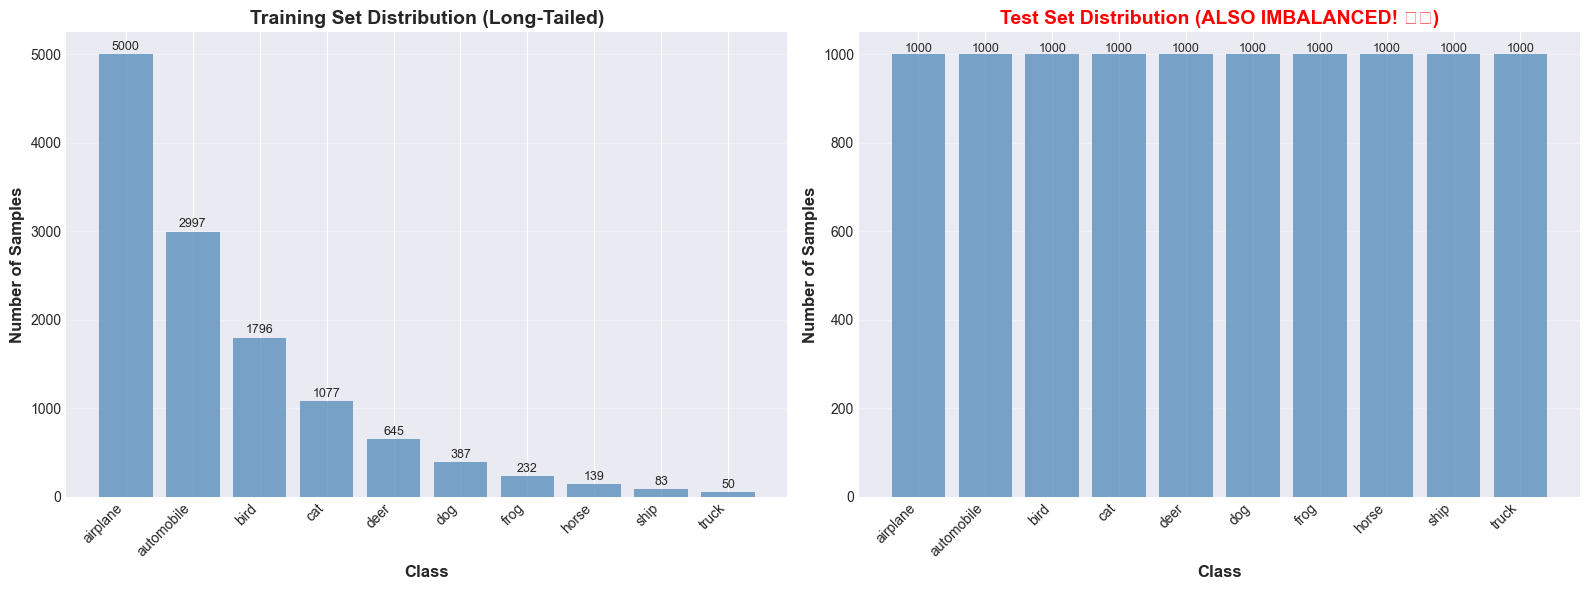


⚠️  PROBLEM IDENTIFIED:
The TEST SET is also long-tailed (imbalanced)!
Expected: Each class should have ~1000 test samples (balanced)
Actual: Test samples range from 1000 to 1000

This is why you're getting low accuracy (~20% on test):
- Minority classes have very few test samples
- The model hasn't seen enough minority class examples during training
- Even worse, it's tested on imbalanced data too!

💡 SOLUTION: The test set should be BALANCED (standard CIFAR-10)


In [36]:
# Check train and test distributions
train_dist = trainset.get_class_distribution()
test_dist = testset.get_class_distribution()

print("="*100)
print("DATASET DISTRIBUTION ANALYSIS")
print("="*100)
print(f"\n{'Class':<15} | {'Train Samples':>15} | {'Test Samples':>15} | {'Test Accuracy':>15}")
print("-"*100)

for i in range(num_classes):
    class_name = class_names[i]
    train_count = train_dist[i]
    test_count = test_dist[i]
    test_acc = final_class_acc[i]
    print(f"{i}: {class_name:<12} | {train_count:>15} | {test_count:>15} | {test_acc:>14.2f}%")

print("-"*100)
print(f"{'TOTAL':<15} | {sum(train_dist.values()):>15} | {sum(test_dist.values()):>15} |")
print("="*100)

# Visualize side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train distribution
ax = axes[0]
ax.bar(range(num_classes), [train_dist[i] for i in range(num_classes)], alpha=0.7, color='steelblue')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
ax.set_title('Training Set Distribution (Long-Tailed)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for i in range(num_classes):
    ax.text(i, train_dist[i] + 50, str(train_dist[i]), ha='center', fontsize=9)

# Test distribution
ax = axes[1]
colors_test = ['red' if test_dist[i] < 1000 else 'steelblue' for i in range(num_classes)]
ax.bar(range(num_classes), [test_dist[i] for i in range(num_classes)], alpha=0.7, color=colors_test)
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Samples', fontweight='bold', fontsize=12)
ax.set_title('Test Set Distribution (ALSO IMBALANCED! ⚠️)', fontweight='bold', fontsize=14, color='red')
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
for i in range(num_classes):
    ax.text(i, test_dist[i] + 5, str(test_dist[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'train_test_distribution_comparison.png'), dpi=150)
plt.show()

print("\n" + "="*100)
print("⚠️  PROBLEM IDENTIFIED:")
print("="*100)
print("The TEST SET is also long-tailed (imbalanced)!")
print(f"Expected: Each class should have ~1000 test samples (balanced)")
print(f"Actual: Test samples range from {min(test_dist.values())} to {max(test_dist.values())}")
print("\nThis is why you're getting low accuracy (~20% on test):")
print("- Minority classes have very few test samples")
print("- The model hasn't seen enough minority class examples during training")
print("- Even worse, it's tested on imbalanced data too!")
print("\n💡 SOLUTION: The test set should be BALANCED (standard CIFAR-10)")
print("="*100)

In [37]:
# Expected sample counts for different imbalance ratios
import pandas as pd

def calculate_expected_distribution(imb_ratio):
    """Calculate expected samples per class for exponential imbalance"""
    total_samples = 50000  # CIFAR-10 train set
    img_max = total_samples / 10  # 5000 per class if balanced
    imb_factor = 1.0 / imb_ratio
    
    samples_per_class = []
    for cls_idx in range(10):
        num = img_max * (imb_factor ** (cls_idx / 9.0))
        samples_per_class.append(int(num))
    
    return samples_per_class

# Compare different ratios
ratios = [10, 20, 50, 100, 200]
comparison_data = []

for ratio in ratios:
    dist = calculate_expected_distribution(ratio)
    comparison_data.append({
        'Imbalance Ratio': f'r-{ratio}',
        'Total Samples': sum(dist),
        'Max (Class 0)': dist[0],
        'Min (Class 9)': dist[9],
        'Class 5 samples': dist[5],
        'Expected Difficulty': '⭐' if ratio <= 20 else '⭐⭐' if ratio <= 50 else '⭐⭐⭐'
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("COMPARISON OF IMBALANCE RATIOS")
print("="*100)
display(df_comparison)

print("\n💡 RECOMMENDATIONS:")
print("-"*100)
print("✅ r-10  : EASIEST  - Good for testing if PolicyRL works (min class: 500 samples)")
print("✅ r-20  : MODERATE - Challenging but learnable (min class: 250 samples)")
print("⚠️  r-50  : HARD    - Difficult to learn minority classes (min class: 100 samples)")
print("❌ r-100 : VERY HARD - Your current setting (min class: 50 samples)")  
print("❌ r-200 : EXTREME  - Almost impossible without specialized techniques (min class: 25 samples)")
print("\nTo change: In cell 7, modify:")
print("  dataset_name = 'r-10'  # Change from 'r-100'")
print("  imbalance_ratio = 10   # Change from 100")
print("="*100)


COMPARISON OF IMBALANCE RATIOS


,Imbalance Ratio,Total Samples,Max (Class 0),Min (Class 9),Class 5 samples,Expected Difficulty
0,r-10,20431,5000,500,1391,⭐
1,r-20,17023,5000,250,946,⭐
2,r-50,13996,5000,100,568,⭐⭐
3,r-100,12406,5000,50,387,⭐⭐⭐
4,r-200,11203,5000,25,263,⭐⭐⭐



💡 RECOMMENDATIONS:
----------------------------------------------------------------------------------------------------
✅ r-10  : EASIEST  - Good for testing if PolicyRL works (min class: 500 samples)
✅ r-20  : MODERATE - Challenging but learnable (min class: 250 samples)
⚠️  r-50  : HARD    - Difficult to learn minority classes (min class: 100 samples)
❌ r-100 : VERY HARD - Your current setting (min class: 50 samples)
❌ r-200 : EXTREME  - Almost impossible without specialized techniques (min class: 25 samples)

To change: In cell 7, modify:
  dataset_name = 'r-10'  # Change from 'r-100'
  imbalance_ratio = 10   # Change from 100


Analyzing confidence scores across classes...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)



CONFIDENCE SCORE ANALYSIS


,class,class_name,train_samples,mean_confidence,std_confidence,mean_correct_conf,mean_incorrect_conf,num_samples
0,0,airplane,5000,0.981760,0.066741,0.987621,0.815240,1000
1,1,automobile,2997,0.992994,0.040834,0.996197,0.807780,1000
2,2,bird,1796,0.940308,0.129480,0.963850,0.812937,1000
3,3,cat,1077,0.859219,0.167790,0.893601,0.772964,1000
4,4,deer,645,0.919910,0.147209,0.950057,0.779736,1000
5,5,dog,387,0.853660,0.165587,0.897087,0.781897,1000
6,6,frog,232,0.898225,0.162212,0.945400,0.755175,1000
7,7,horse,139,0.836289,0.179364,0.893127,0.774715,1000
8,8,ship,83,0.898440,0.156682,0.924395,0.874094,1000
9,9,truck,50,0.883193,0.159467,0.896893,0.871984,1000


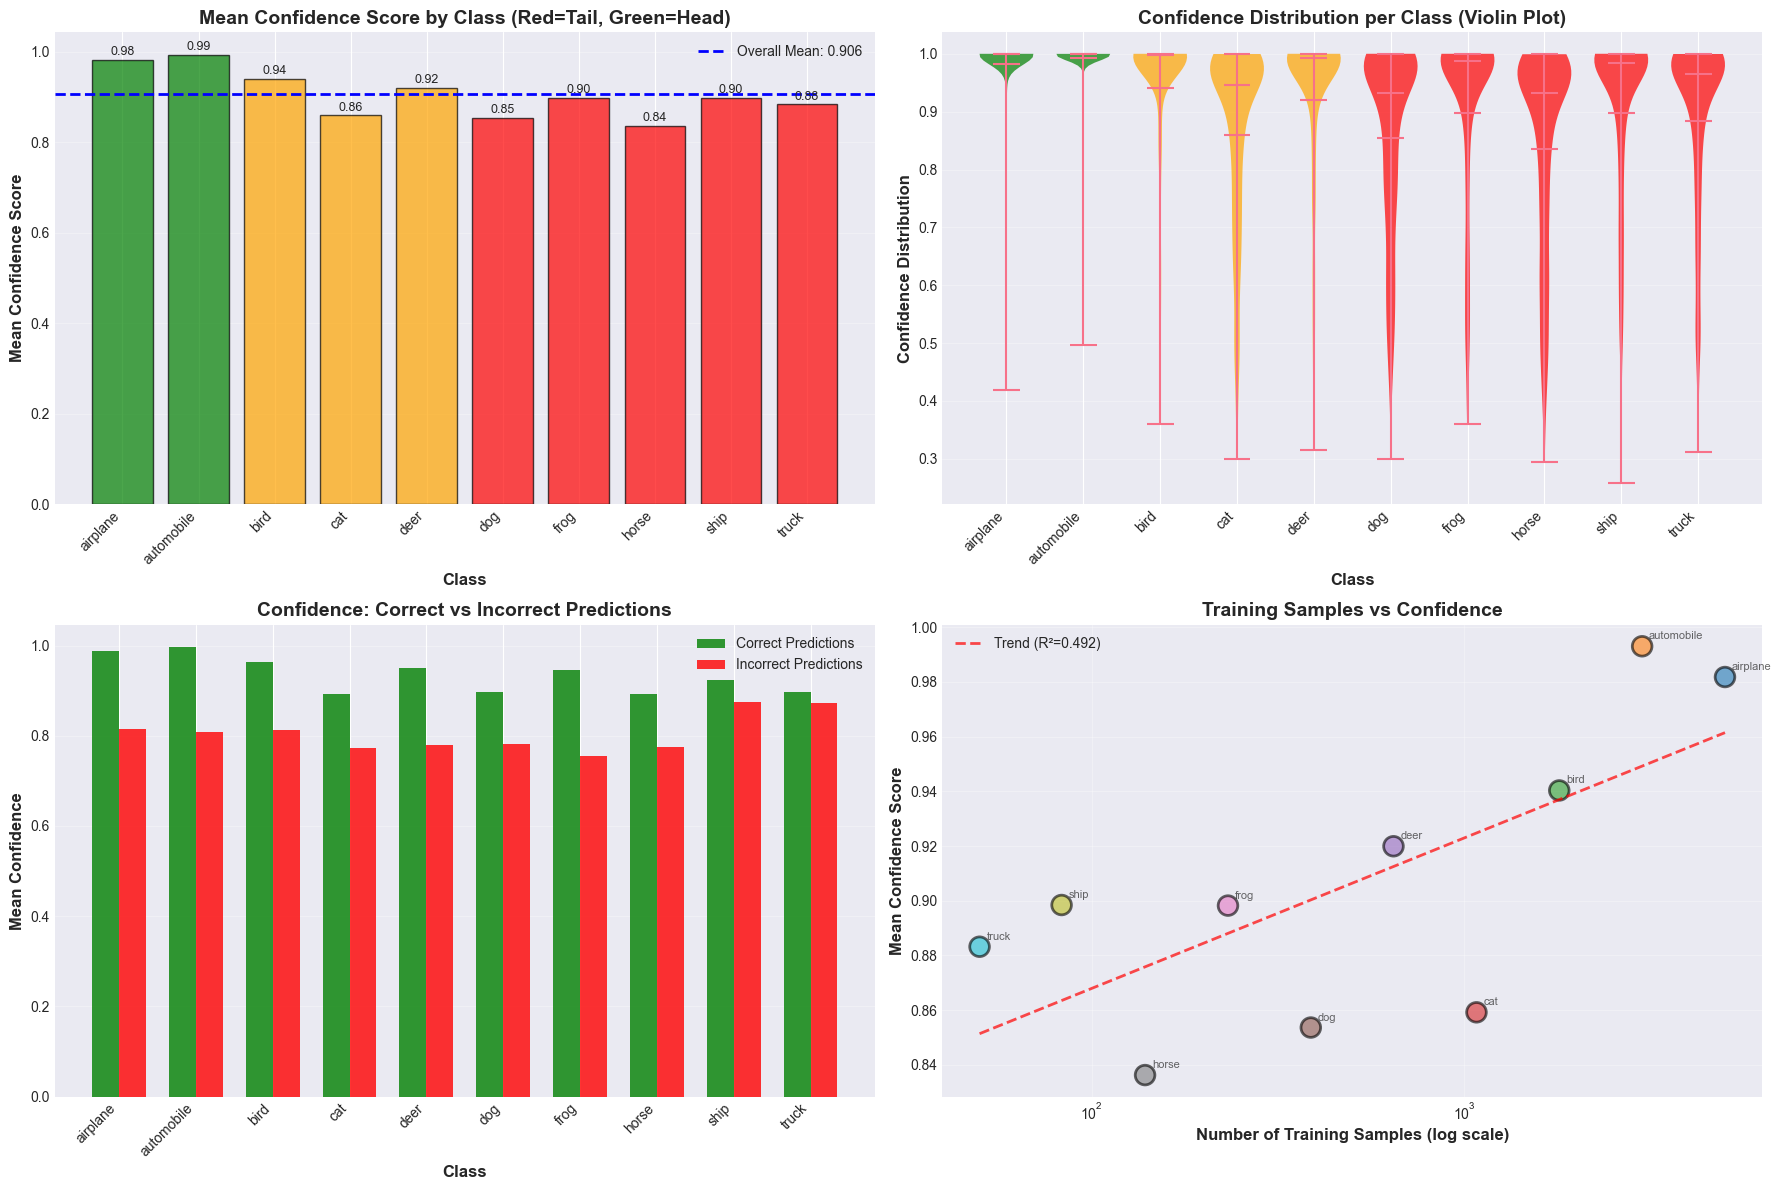


📊 Confidence analysis saved to ./checkpoints/policyrl_longtailed_ir100/confidence_analysis.png

KEY INSIGHTS - CONFIDENCE ANALYSIS:
• Correlation (Training Samples vs Confidence): 0.807 (p=0.0048)
• Head Classes (≥2000 samples) Mean Confidence: 0.987
• Tail Classes (<500 samples) Mean Confidence: 0.874
• Confidence Gap (Head - Tail): 0.113

⚠️  WARNING: Significant confidence gap detected!
   The model is overconfident on head classes and underconfident on tail classes.
   This suggests the model is biased towards majority classes.


In [38]:
# Analyze confidence scores for each class
print("Analyzing confidence scores across classes...")

model.eval()
class_confidences = {i: [] for i in range(num_classes)}
class_correct_confidences = {i: [] for i in range(num_classes)}
class_incorrect_confidences = {i: [] for i in range(num_classes)}

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        
        # Get probabilities for classification
        probs = F.softmax(outputs, dim=1)
        max_probs, predictions = probs.max(1)
        
        # Store confidence scores per class
        for i in range(len(targets)):
            true_class = targets[i].item()
            confidence = max_probs[i].item()
            is_correct = (predictions[i] == targets[i]).item()
            
            class_confidences[true_class].append(confidence)
            
            if is_correct:
                class_correct_confidences[true_class].append(confidence)
            else:
                class_incorrect_confidences[true_class].append(confidence)

# Calculate statistics
confidence_stats = []
for i in range(num_classes):
    stats = {
        'class': i,
        'class_name': class_names[i],
        'train_samples': train_dist[i],
        'mean_confidence': np.mean(class_confidences[i]),
        'std_confidence': np.std(class_confidences[i]),
        'mean_correct_conf': np.mean(class_correct_confidences[i]) if class_correct_confidences[i] else 0.0,
        'mean_incorrect_conf': np.mean(class_incorrect_confidences[i]) if class_incorrect_confidences[i] else 0.0,
        'num_samples': len(class_confidences[i])
    }
    confidence_stats.append(stats)

df_confidence = pd.DataFrame(confidence_stats)

print("\n" + "="*100)
print("CONFIDENCE SCORE ANALYSIS")
print("="*100)
display(df_confidence)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Mean confidence by class
ax = axes[0, 0]
colors_conf = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
               for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_confidence['mean_confidence'], color=colors_conf, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence Score', fontweight='bold', fontsize=12)
ax.set_title('Mean Confidence Score by Class (Red=Tail, Green=Head)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=df_confidence['mean_confidence'].mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {df_confidence["mean_confidence"].mean():.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, conf in enumerate(df_confidence['mean_confidence']):
    ax.text(i, conf + 0.01, f'{conf:.2f}', ha='center', fontsize=9)

# 2. Confidence distribution (violin plot)
ax = axes[0, 1]
positions = []
data_to_plot = []
colors_violin = []
for i in range(num_classes):
    if class_confidences[i]:
        positions.append(i)
        data_to_plot.append(class_confidences[i])
        colors_violin.append('red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green')

parts = ax.violinplot(data_to_plot, positions=positions, widths=0.7, showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], colors_violin):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Confidence Distribution', fontweight='bold', fontsize=12)
ax.set_title('Confidence Distribution per Class (Violin Plot)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')

# 3. Correct vs Incorrect Confidence
ax = axes[1, 0]
x = np.arange(num_classes)
width = 0.35
correct_confs = df_confidence['mean_correct_conf']
incorrect_confs = df_confidence['mean_incorrect_conf']

bars1 = ax.bar(x - width/2, correct_confs, width, label='Correct Predictions', alpha=0.8, color='green')
bars2 = ax.bar(x + width/2, incorrect_confs, width, label='Incorrect Predictions', alpha=0.8, color='red')

ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence', fontweight='bold', fontsize=12)
ax.set_title('Confidence: Correct vs Incorrect Predictions', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Training samples vs Confidence
ax = axes[1, 1]
train_samples = [train_dist[i] for i in range(num_classes)]
scatter = ax.scatter(train_samples, df_confidence['mean_confidence'], 
                    s=200, alpha=0.6, c=range(num_classes), cmap='tab10', 
                    edgecolors='black', linewidth=2)
ax.set_xlabel('Number of Training Samples (log scale)', fontweight='bold', fontsize=12)
ax.set_ylabel('Mean Confidence Score', fontweight='bold', fontsize=12)
ax.set_title('Training Samples vs Confidence', fontweight='bold', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# Add class labels
for i, name in enumerate(class_names):
    ax.annotate(name, (train_samples[i], df_confidence['mean_confidence'].iloc[i]), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

# Add trend line
from scipy import stats
log_samples = np.log10(train_samples)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_samples, df_confidence['mean_confidence'])
trend_x = np.array([min(train_samples), max(train_samples)])
trend_y = slope * np.log10(trend_x) + intercept
ax.plot(trend_x, trend_y, 'r--', linewidth=2, alpha=0.7, 
        label=f'Trend (R²={r_value**2:.3f})')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'confidence_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Confidence analysis saved to {config.save_dir}/confidence_analysis.png")

# Key insights
print("\n" + "="*100)
print("KEY INSIGHTS - CONFIDENCE ANALYSIS:")
print("="*100)

# Calculate correlation
from scipy.stats import pearsonr
corr, p_val = pearsonr(train_samples, df_confidence['mean_confidence'])
print(f"• Correlation (Training Samples vs Confidence): {corr:.3f} (p={p_val:.4f})")

# Head vs Tail comparison
head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

head_conf = df_confidence[df_confidence['class'].isin(head_classes)]['mean_confidence'].mean()
tail_conf = df_confidence[df_confidence['class'].isin(tail_classes)]['mean_confidence'].mean()

print(f"• Head Classes (≥2000 samples) Mean Confidence: {head_conf:.3f}")
print(f"• Tail Classes (<500 samples) Mean Confidence: {tail_conf:.3f}")
print(f"• Confidence Gap (Head - Tail): {head_conf - tail_conf:.3f}")

if head_conf - tail_conf > 0.05:
    print("\n⚠️  WARNING: Significant confidence gap detected!")
    print("   The model is overconfident on head classes and underconfident on tail classes.")
    print("   This suggests the model is biased towards majority classes.")

print("="*100)

Analyzing misclassification patterns...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


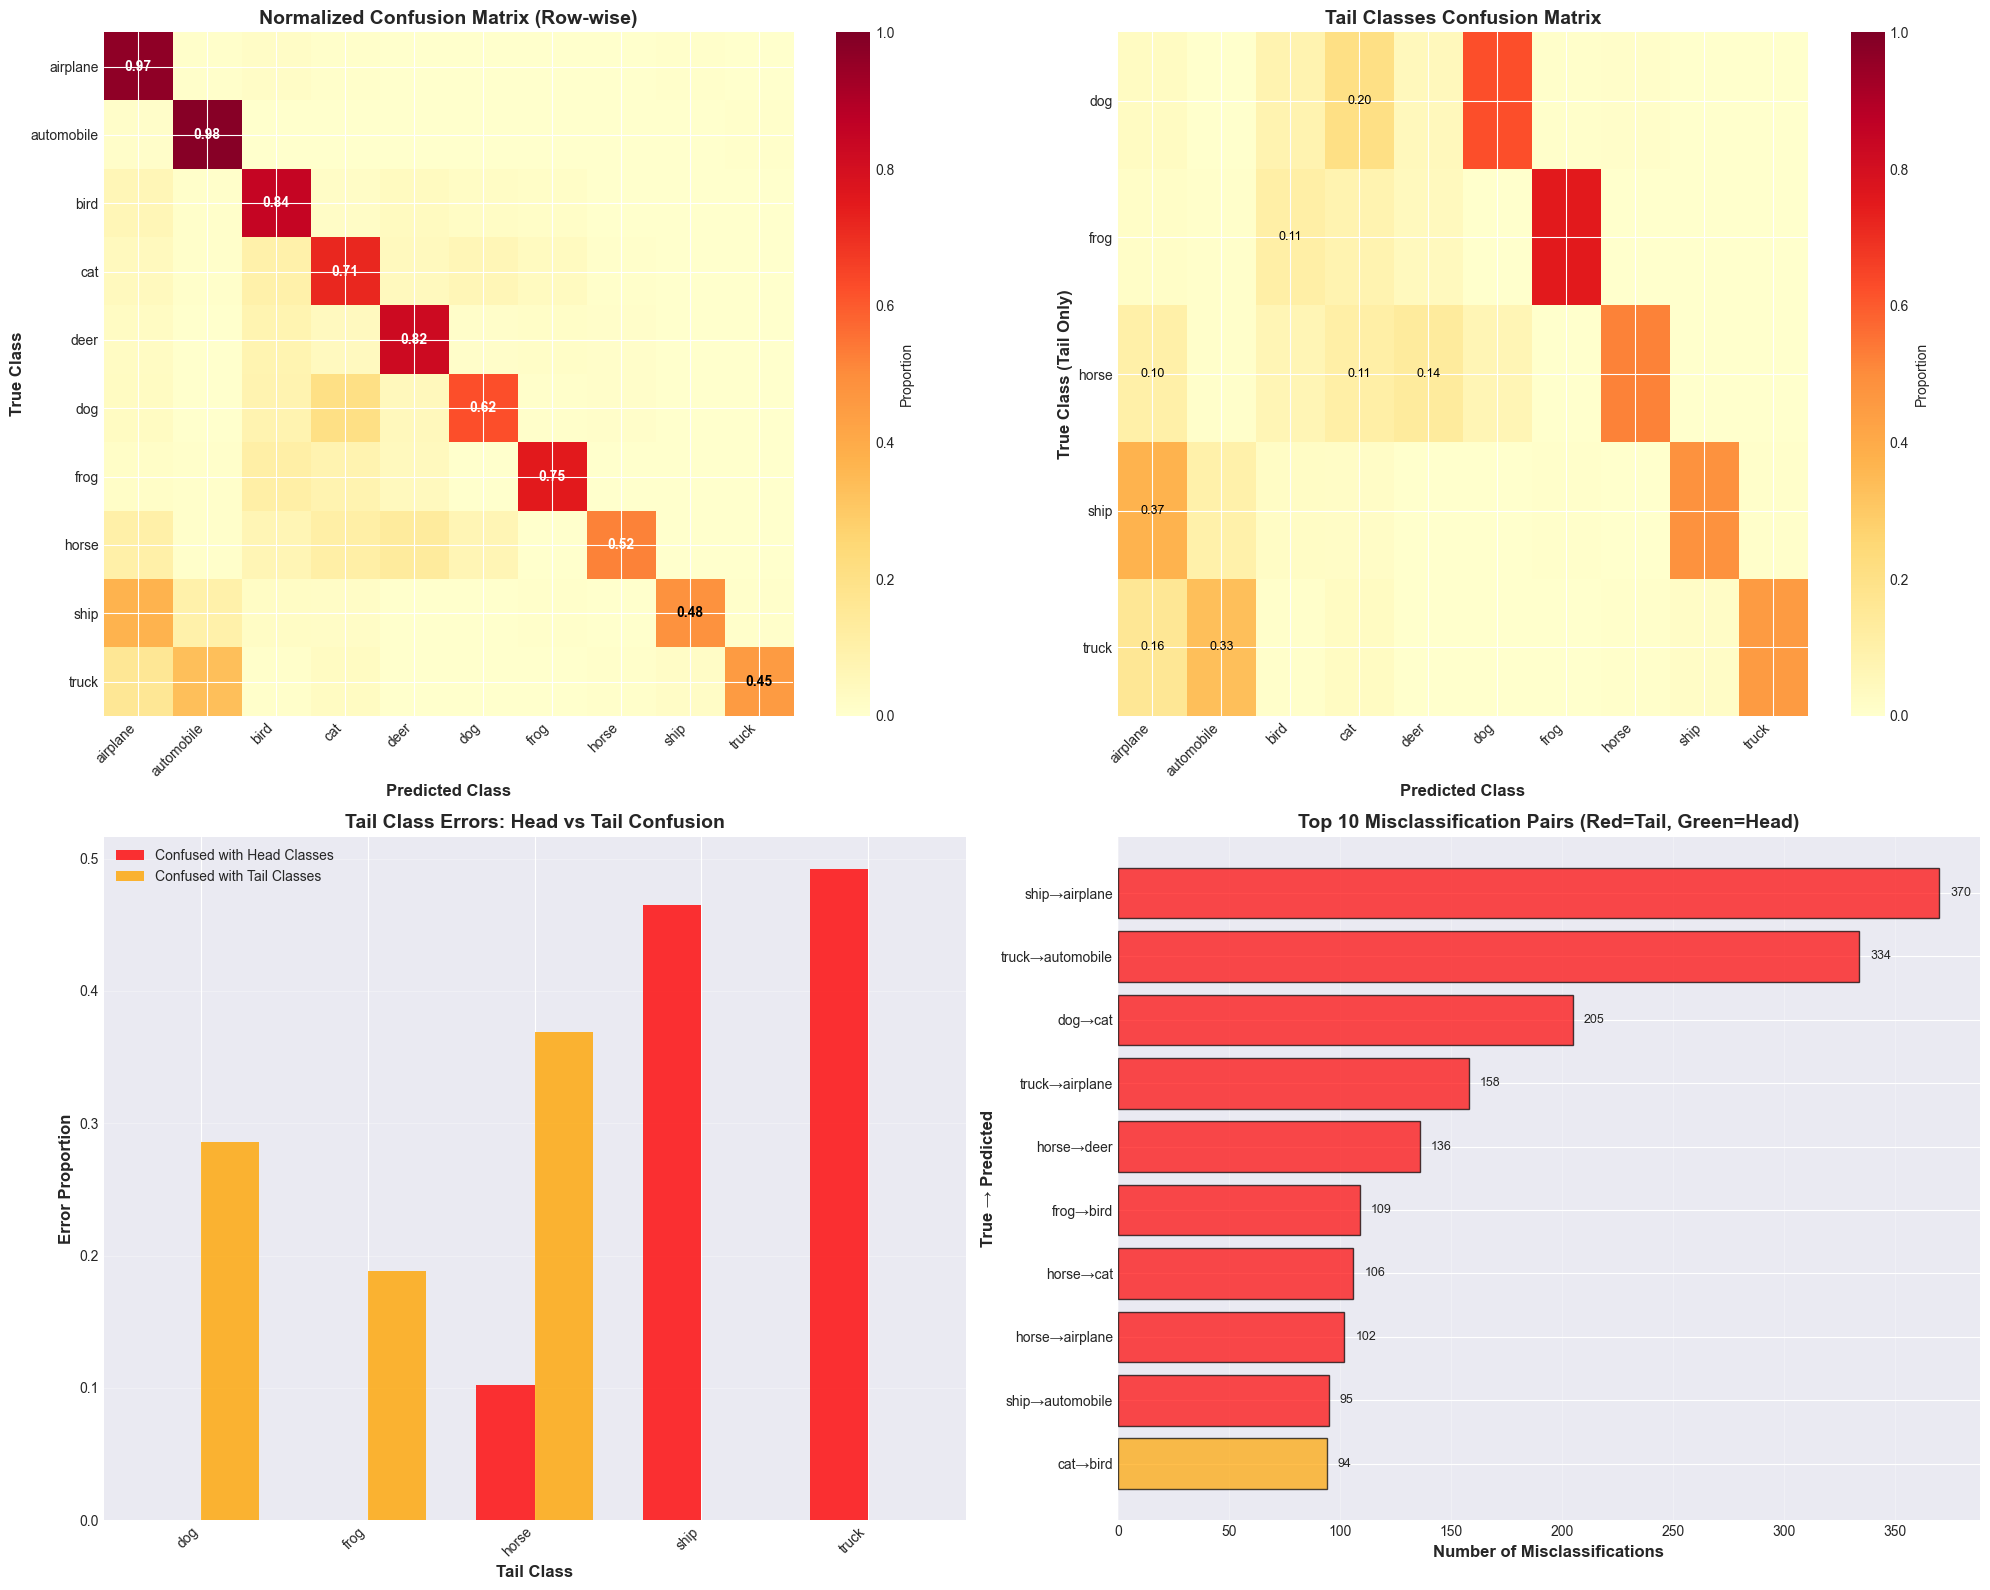


📊 Misclassification analysis saved to ./checkpoints/policyrl_longtailed_ir100/misclassification_analysis.png

KEY INSIGHTS - MISCLASSIFICATION PATTERNS:
• Total Misclassifications: 2840

• Tail Classes (<500 samples):

  dog (Class 5, 387 samples):
    1. Confused with cat (1077 samples): 20.5%
    2. Confused with bird (1796 samples): 8.1%
    3. Confused with deer (645 samples): 4.4%

  frog (Class 6, 232 samples):
    1. Confused with bird (1796 samples): 10.9%
    2. Confused with cat (1077 samples): 7.9%
    3. Confused with deer (645 samples): 4.1%

  horse (Class 7, 139 samples):
    1. Confused with deer (645 samples): 13.6%
    2. Confused with cat (1077 samples): 10.6%
    3. Confused with airplane (5000 samples): 10.2%

  ship (Class 8, 83 samples):
    1. Confused with airplane (5000 samples): 37.0%
    2. Confused with automobile (2997 samples): 9.5%
    3. Confused with bird (1796 samples): 2.3%

  truck (Class 9, 50 samples):
    1. Confused with automobile (2997 sample

In [39]:
# Build confusion matrix and analyze misclassification patterns
print("Analyzing misclassification patterns...")

model.eval()
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        _, predictions = outputs.max(1)
        
        # Build confusion matrix
        for true_label, pred_label in zip(targets, predictions):
            confusion_matrix[true_label.item()][pred_label.item()] += 1

# Normalize confusion matrix by row (true class)
confusion_matrix_norm = confusion_matrix.astype(float)
for i in range(num_classes):
    row_sum = confusion_matrix_norm[i].sum()
    if row_sum > 0:
        confusion_matrix_norm[i] = confusion_matrix_norm[i] / row_sum

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Full Confusion Matrix (normalized)
ax = axes[0, 0]
im = ax.imshow(confusion_matrix_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=12)
ax.set_ylabel('True Class', fontweight='bold', fontsize=12)
ax.set_title('Normalized Confusion Matrix (Row-wise)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# Add text annotations for diagonal (accuracy)
for i in range(num_classes):
    text = ax.text(i, i, f'{confusion_matrix_norm[i, i]:.2f}',
                   ha="center", va="center", color="white" if confusion_matrix_norm[i, i] > 0.5 else "black",
                   fontweight='bold', fontsize=10)

plt.colorbar(im, ax=ax, label='Proportion')

# 2. Tail Classes Confusion (focus on tail classes)
ax = axes[0, 1]
tail_classes_idx = [i for i in range(num_classes) if train_dist[i] < 500]
if tail_classes_idx:
    tail_confusion = confusion_matrix_norm[tail_classes_idx, :]
    im2 = ax.imshow(tail_confusion, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xlabel('Predicted Class', fontweight='bold', fontsize=12)
    ax.set_ylabel('True Class (Tail Only)', fontweight='bold', fontsize=12)
    ax.set_title('Tail Classes Confusion Matrix', fontweight='bold', fontsize=14)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(len(tail_classes_idx)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels([class_names[i] for i in tail_classes_idx])
    
    # Annotate top misclassifications
    for i, true_idx in enumerate(tail_classes_idx):
        for j in range(num_classes):
            if j != true_idx and tail_confusion[i, j] > 0.1:  # Significant confusion
                ax.text(j, i, f'{tail_confusion[i, j]:.2f}',
                       ha="center", va="center", color="white" if tail_confusion[i, j] > 0.5 else "black",
                       fontsize=9)
    
    plt.colorbar(im2, ax=ax, label='Proportion')

# 3. Misclassification Patterns (Where do tail classes get confused?)
ax = axes[1, 0]
tail_to_head_errors = []
tail_to_tail_errors = []
tail_class_names = []

for true_class in range(num_classes):
    if train_dist[true_class] < 500:  # Tail class
        # Find top-3 confused classes (excluding itself)
        confused_with = []
        for pred_class in range(num_classes):
            if pred_class != true_class and confusion_matrix_norm[true_class, pred_class] > 0.05:
                is_head = train_dist[pred_class] >= 2000
                confused_with.append({
                    'pred_class': pred_class,
                    'pred_name': class_names[pred_class],
                    'proportion': confusion_matrix_norm[true_class, pred_class],
                    'is_head': is_head,
                    'samples': train_dist[pred_class]
                })
        
        # Sort by proportion
        confused_with.sort(key=lambda x: x['proportion'], reverse=True)
        
        # Calculate tail-to-head vs tail-to-tail
        head_error = sum([c['proportion'] for c in confused_with if c['is_head']])
        tail_error = sum([c['proportion'] for c in confused_with if not c['is_head']])
        
        tail_to_head_errors.append(head_error)
        tail_to_tail_errors.append(tail_error)
        tail_class_names.append(class_names[true_class])

x = np.arange(len(tail_class_names))
width = 0.35

bars1 = ax.bar(x - width/2, tail_to_head_errors, width, label='Confused with Head Classes', 
               alpha=0.8, color='red')
bars2 = ax.bar(x + width/2, tail_to_tail_errors, width, label='Confused with Tail Classes', 
               alpha=0.8, color='orange')

ax.set_xlabel('Tail Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Proportion', fontweight='bold', fontsize=12)
ax.set_title('Tail Class Errors: Head vs Tail Confusion', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(tail_class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 4. Top Misclassification Pairs
ax = axes[1, 1]
misclass_pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and confusion_matrix[i, j] > 0:
            misclass_pairs.append({
                'true_class': i,
                'true_name': class_names[i],
                'pred_class': j,
                'pred_name': class_names[j],
                'count': confusion_matrix[i, j],
                'proportion': confusion_matrix_norm[i, j],
                'true_samples': train_dist[i],
                'pred_samples': train_dist[j]
            })

# Sort by count
misclass_pairs.sort(key=lambda x: x['count'], reverse=True)
top_10 = misclass_pairs[:10]

# Create bar chart
pair_labels = [f"{p['true_name']}→{p['pred_name']}" for p in top_10]
pair_counts = [p['count'] for p in top_10]
pair_colors = ['red' if p['true_samples'] < 500 else 'orange' if p['true_samples'] < 2000 else 'green' 
               for p in top_10]

bars = ax.barh(range(len(pair_labels)), pair_counts, color=pair_colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel('Number of Misclassifications', fontweight='bold', fontsize=12)
ax.set_ylabel('True → Predicted', fontweight='bold', fontsize=12)
ax.set_title('Top 10 Misclassification Pairs (Red=Tail, Green=Head)', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

# Add value labels
for i, (bar, count) in enumerate(zip(bars, pair_counts)):
    ax.text(count + 5, i, f'{count}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'misclassification_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Misclassification analysis saved to {config.save_dir}/misclassification_analysis.png")

# Detailed analysis
print("\n" + "="*100)
print("KEY INSIGHTS - MISCLASSIFICATION PATTERNS:")
print("="*100)

# Overall statistics
total_errors = confusion_matrix.sum() - np.trace(confusion_matrix)
print(f"• Total Misclassifications: {total_errors}")

# Tail class analysis
print(f"\n• Tail Classes (<500 samples):")
for true_class in range(num_classes):
    if train_dist[true_class] < 500:
        # Find top-3 confused classes
        confused_indices = np.argsort(confusion_matrix_norm[true_class])[::-1]
        confused_indices = [i for i in confused_indices if i != true_class][:3]
        
        print(f"\n  {class_names[true_class]} (Class {true_class}, {train_dist[true_class]} samples):")
        for rank, pred_class in enumerate(confused_indices, 1):
            if confusion_matrix_norm[true_class, pred_class] > 0.01:
                print(f"    {rank}. Confused with {class_names[pred_class]} "
                      f"({train_dist[pred_class]} samples): {confusion_matrix_norm[true_class, pred_class]*100:.1f}%")

# Head vs Tail bias
if tail_to_head_errors and tail_to_tail_errors:
    avg_tail_to_head = np.mean(tail_to_head_errors)
    avg_tail_to_tail = np.mean(tail_to_tail_errors)
    print(f"\n• Average Tail Class Error:")
    print(f"  - Confused with Head Classes: {avg_tail_to_head*100:.1f}%")
    print(f"  - Confused with Tail Classes: {avg_tail_to_tail*100:.1f}%")
    
    if avg_tail_to_head > avg_tail_to_tail:
        print("\n⚠️  WARNING: Tail classes are more often misclassified as HEAD classes!")
        print("   This indicates a strong bias towards majority classes.")

print("="*100)

Extracting feature representations...
Feature shape: (10000, 512)
Number of samples: 10000

Sampled 2000 points for t-SNE visualization
Running t-SNE (this may take a few minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.000s...
[t-SNE] Computed neighbors for 2000 samples in 0.127s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 0.475844
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.641911
[t-SNE] KL divergence after 1000 iterations: 0.666778
t-SNE completed!


/tmp/ipykernel_70741/1716149421.py:122: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(features_2d[incorrect_mask, 0], features_2d[incorrect_mask, 1],


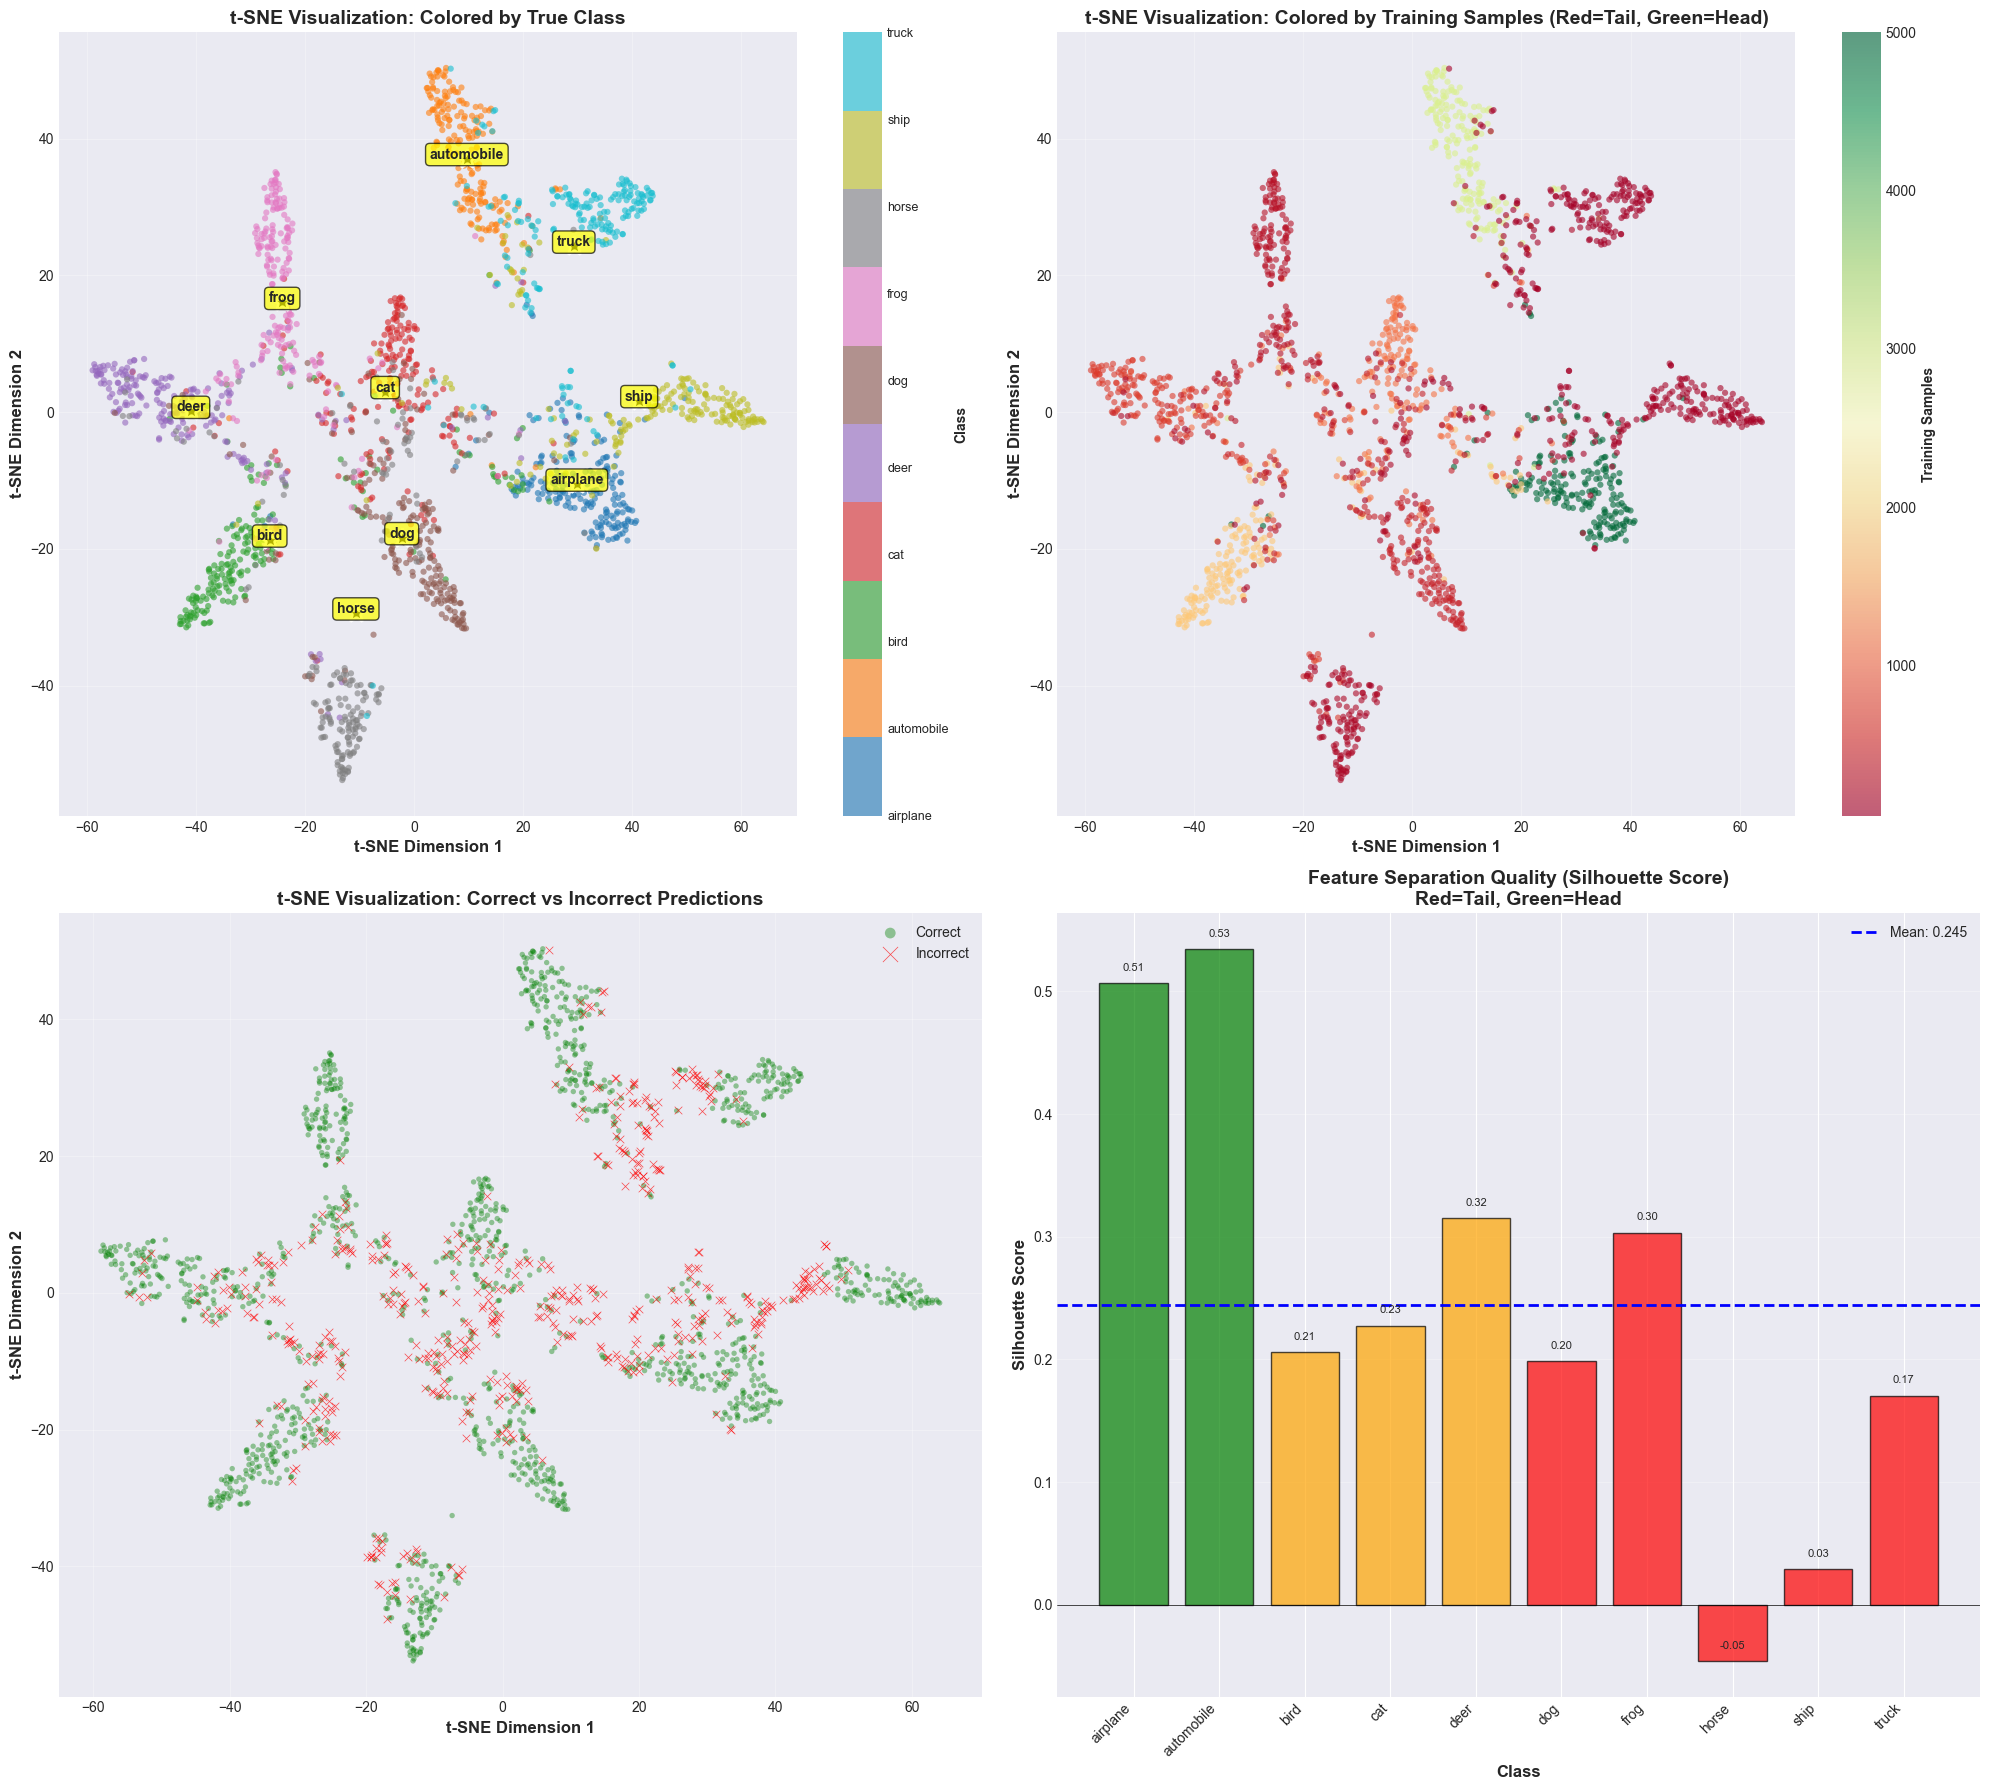


📊 t-SNE feature analysis saved to ./checkpoints/policyrl_longtailed_ir100/tsne_feature_analysis.png

KEY INSIGHTS - FEATURE REPRESENTATION:
• Overall Mean Silhouette Score: 0.245
  (Range: -1 to 1, higher is better separation)

• Head Classes Silhouette: 0.521
• Tail Classes Silhouette: 0.131
• Separation Gap (Head - Tail): 0.390

⚠️  WARNING: Tail classes have poor feature separation!
   Features of tail classes overlap significantly with other classes.
   The model struggles to learn discriminative features for minority classes.

⚠️  WARNING: Large separation gap between head and tail classes!
   The model learns much better representations for majority classes.

• Classes with Worst Feature Separation:
  - horse: -0.046 (139 samples)
  - ship: 0.029 (83 samples)
  - truck: 0.170 (50 samples)


In [40]:
# Extract features from the last layer before classifier
print("Extracting feature representations...")

# Create a feature extractor (remove classifier)
if use_cuda:
    feature_extractor = nn.Sequential(*list(model.module.features.children()))
else:
    feature_extractor = nn.Sequential(*list(model.features.children()))

feature_extractor.eval()

all_features = []
all_labels = []
all_predictions = []

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        # Extract features
        features = feature_extractor(inputs)
        features = features.view(features.size(0), -1)  # Flatten
        
        # Get predictions
        outputs = model(inputs).cpu()
        _, predictions = outputs.max(1)
        
        all_features.append(features.cpu().numpy())
        all_labels.append(targets.numpy())
        all_predictions.append(predictions.numpy())

# Concatenate all batches
all_features = np.vstack(all_features)
all_labels = np.concatenate(all_labels)
all_predictions = np.concatenate(all_predictions)

print(f"Feature shape: {all_features.shape}")
print(f"Number of samples: {len(all_labels)}")

# Sample subset for t-SNE (for computational efficiency)
n_samples_per_class = 200
sampled_indices = []
for c in range(num_classes):
    class_indices = np.where(all_labels == c)[0]
    if len(class_indices) > n_samples_per_class:
        sampled = np.random.choice(class_indices, n_samples_per_class, replace=False)
    else:
        sampled = class_indices
    sampled_indices.extend(sampled)

sampled_indices = np.array(sampled_indices)
sampled_features = all_features[sampled_indices]
sampled_labels = all_labels[sampled_indices]
sampled_predictions = all_predictions[sampled_indices]

print(f"\nSampled {len(sampled_indices)} points for t-SNE visualization")

# Perform t-SNE
print("Running t-SNE (this may take a few minutes)...")
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=config.manual_seed, perplexity=30, n_iter=1000, verbose=1)
features_2d = tsne.fit_transform(sampled_features)

print("t-SNE completed!")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# 1. t-SNE colored by true class
ax = axes[0, 0]
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                    c=sampled_labels, cmap='tab10', 
                    s=20, alpha=0.6, edgecolors='none')
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Colored by True Class', fontweight='bold', fontsize=14)

# Add legend
cbar = plt.colorbar(scatter, ax=ax, ticks=range(num_classes))
cbar.set_label('Class', fontweight='bold')
cbar.ax.set_yticklabels(class_names, fontsize=9)

# Add class centroids
for c in range(num_classes):
    mask = sampled_labels == c
    if mask.sum() > 0:
        centroid = features_2d[mask].mean(axis=0)
        ax.plot(centroid[0], centroid[1], 'k*', markersize=15, markeredgewidth=2, 
                markeredgecolor='white', zorder=10)
        ax.annotate(class_names[c], centroid, fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   ha='center', zorder=11)

ax.grid(True, alpha=0.3)

# 2. t-SNE colored by training samples (head vs tail)
ax = axes[0, 1]
colors_samples = np.array([train_dist[label] for label in sampled_labels])
scatter = ax.scatter(features_2d[:, 0], features_2d[:, 1], 
                    c=colors_samples, cmap='RdYlGn', 
                    s=20, alpha=0.6, edgecolors='none', norm=plt.Normalize(vmin=50, vmax=5000))
ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Colored by Training Samples (Red=Tail, Green=Head)', 
             fontweight='bold', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Training Samples', fontweight='bold')
ax.grid(True, alpha=0.3)

# 3. Correct vs Incorrect predictions
ax = axes[1, 0]
correct_mask = sampled_labels == sampled_predictions
incorrect_mask = ~correct_mask

ax.scatter(features_2d[correct_mask, 0], features_2d[correct_mask, 1], 
          c='green', s=15, alpha=0.4, label='Correct', edgecolors='none')
ax.scatter(features_2d[incorrect_mask, 0], features_2d[incorrect_mask, 1], 
          c='red', s=30, alpha=0.7, label='Incorrect', edgecolors='black', linewidths=0.5, marker='x')

ax.set_xlabel('t-SNE Dimension 1', fontweight='bold', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontweight='bold', fontsize=12)
ax.set_title('t-SNE Visualization: Correct vs Incorrect Predictions', fontweight='bold', fontsize=14)
ax.legend(markerscale=2)
ax.grid(True, alpha=0.3)

# 4. Per-class separation quality (using silhouette score)
from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(features_2d, sampled_labels)

# Calculate per-class silhouette scores
class_silhouettes = []
for c in range(num_classes):
    mask = sampled_labels == c
    if mask.sum() > 0:
        class_sil = silhouette_vals[mask].mean()
        class_silhouettes.append({
            'class': c,
            'class_name': class_names[c],
            'silhouette': class_sil,
            'train_samples': train_dist[c]
        })

df_silhouette = pd.DataFrame(class_silhouettes)

ax = axes[1, 1]
colors_sil = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
              for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_silhouette['silhouette'], 
             color=colors_sil, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Silhouette Score', fontweight='bold', fontsize=12)
ax.set_title('Feature Separation Quality (Silhouette Score)\nRed=Tail, Green=Head', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.axhline(y=df_silhouette['silhouette'].mean(), color='blue', linestyle='--', linewidth=2,
          label=f'Mean: {df_silhouette["silhouette"].mean():.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, sil in enumerate(df_silhouette['silhouette']):
    ax.text(i, sil + 0.01, f'{sil:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'tsne_feature_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 t-SNE feature analysis saved to {config.save_dir}/tsne_feature_analysis.png")

# Analysis
print("\n" + "="*100)
print("KEY INSIGHTS - FEATURE REPRESENTATION:")
print("="*100)

print(f"• Overall Mean Silhouette Score: {df_silhouette['silhouette'].mean():.3f}")
print(f"  (Range: -1 to 1, higher is better separation)")

# Head vs Tail comparison
head_sil = df_silhouette[df_silhouette['train_samples'] >= 2000]['silhouette'].mean()
tail_sil = df_silhouette[df_silhouette['train_samples'] < 500]['silhouette'].mean()

print(f"\n• Head Classes Silhouette: {head_sil:.3f}")
print(f"• Tail Classes Silhouette: {tail_sil:.3f}")
print(f"• Separation Gap (Head - Tail): {head_sil - tail_sil:.3f}")

if tail_sil < 0.2:
    print("\n⚠️  WARNING: Tail classes have poor feature separation!")
    print("   Features of tail classes overlap significantly with other classes.")
    print("   The model struggles to learn discriminative features for minority classes.")

if head_sil - tail_sil > 0.1:
    print("\n⚠️  WARNING: Large separation gap between head and tail classes!")
    print("   The model learns much better representations for majority classes.")

# Identify most problematic classes
worst_classes = df_silhouette.nsmallest(3, 'silhouette')
print(f"\n• Classes with Worst Feature Separation:")
for idx, row in worst_classes.iterrows():
    print(f"  - {row['class_name']}: {row['silhouette']:.3f} ({row['train_samples']} samples)")

print("="*100)

Analyzing model calibration...


/home/haipham2407/miniconda3/envs/l2r/lib/python3.11/site-packages/torch/nn/functional.py:1331: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)
/tmp/ipykernel_70741/681869281.py:159: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(df_calibration.loc[c, 'mean_confidence'],


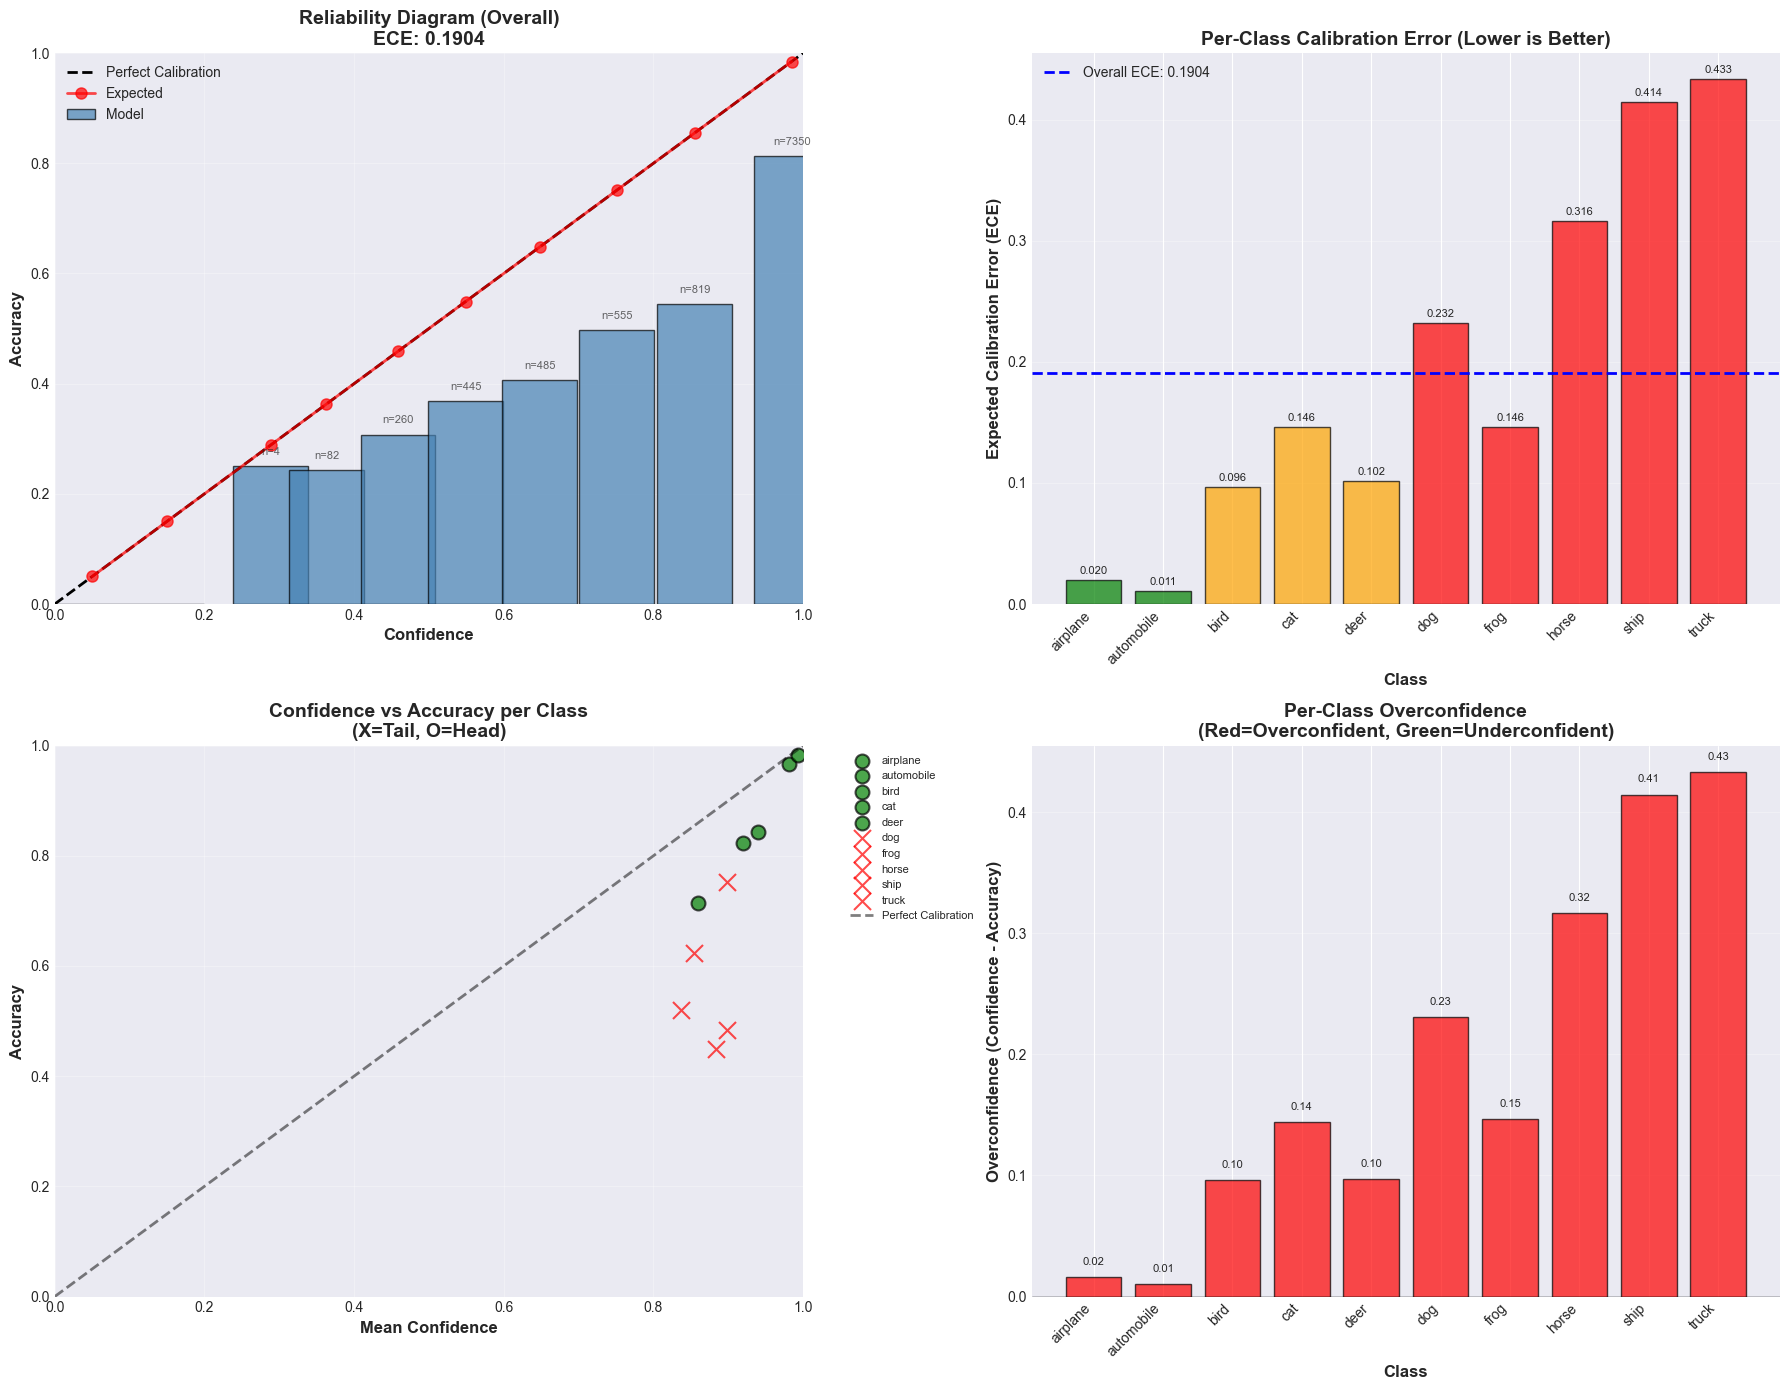


📊 Calibration analysis saved to ./checkpoints/policyrl_longtailed_ir100/calibration_analysis.png

KEY INSIGHTS - CALIBRATION:
• Overall Expected Calibration Error (ECE): 0.1904
  (Range: 0 to 1, lower is better. <0.05 is well-calibrated)

• Head Classes ECE: 0.0154
• Tail Classes ECE: 0.3085
• Calibration Gap (Tail - Head): 0.2931

• Head Classes Overconfidence: 0.0129
• Tail Classes Overconfidence: 0.3082

⚠️  WARNING: Model is poorly calibrated overall!
   Confidence scores do not match actual accuracy.

⚠️  WARNING: Tail classes are significantly worse calibrated!
   The model's confidence is less reliable for minority classes.

⚠️  WARNING: Model is overconfident on tail classes!
   Despite low accuracy, the model assigns high confidence to tail class predictions.

• Most Miscalibrated Classes:
  - truck: ECE=0.4332, Overconf=0.4332 (50 samples)
  - ship: ECE=0.4144, Overconf=0.4144 (83 samples)
  - horse: ECE=0.3163, Overconf=0.3163 (139 samples)


In [41]:
# Calibration analysis: confidence vs accuracy
print("Analyzing model calibration...")

model.eval()

# Collect predictions with confidence scores
all_confidences = []
all_correct = []
all_true_labels = []

with torch.no_grad():
    for batch_data in testloader:
        inputs, targets, indices = batch_data
        
        if use_cuda:
            inputs = inputs.cuda()
        
        outputs = model(inputs).cpu()
        probs = F.softmax(outputs, dim=1)
        confidences, predictions = probs.max(1)
        
        correct = (predictions == targets).numpy()
        
        all_confidences.extend(confidences.numpy())
        all_correct.extend(correct)
        all_true_labels.extend(targets.numpy())

all_confidences = np.array(all_confidences)
all_correct = np.array(all_correct)
all_true_labels = np.array(all_true_labels)

# Create confidence bins
n_bins = 10
bin_boundaries = np.linspace(0, 1, n_bins + 1)
bin_lowers = bin_boundaries[:-1]
bin_uppers = bin_boundaries[1:]

# Calculate calibration metrics
bin_accuracies = []
bin_confidences = []
bin_counts = []

for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
    in_bin = (all_confidences > bin_lower) & (all_confidences <= bin_upper)
    bin_count = in_bin.sum()
    
    if bin_count > 0:
        bin_accuracy = all_correct[in_bin].mean()
        bin_confidence = all_confidences[in_bin].mean()
    else:
        bin_accuracy = 0
        bin_confidence = (bin_lower + bin_upper) / 2
    
    bin_accuracies.append(bin_accuracy)
    bin_confidences.append(bin_confidence)
    bin_counts.append(bin_count)

# Calculate ECE (Expected Calibration Error)
ece = 0
for i in range(n_bins):
    if bin_counts[i] > 0:
        ece += (bin_counts[i] / len(all_confidences)) * abs(bin_accuracies[i] - bin_confidences[i])

# Per-class calibration
class_calibration = []
for c in range(num_classes):
    class_mask = all_true_labels == c
    if class_mask.sum() > 0:
        class_conf = all_confidences[class_mask]
        class_correct = all_correct[class_mask]
        
        # Bin this class's predictions
        class_bin_acc = []
        class_bin_conf = []
        class_bin_counts = []
        
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (class_conf > bin_lower) & (class_conf <= bin_upper)
            bin_count = in_bin.sum()
            
            if bin_count > 0:
                bin_acc = class_correct[in_bin].mean()
                bin_conf_mean = class_conf[in_bin].mean()
            else:
                bin_acc = 0
                bin_conf_mean = (bin_lower + bin_upper) / 2
            
            class_bin_acc.append(bin_acc)
            class_bin_conf.append(bin_conf_mean)
            class_bin_counts.append(bin_count)
        
        # Calculate class ECE
        class_ece = 0
        for i in range(n_bins):
            if class_bin_counts[i] > 0:
                class_ece += (class_bin_counts[i] / class_mask.sum()) * abs(class_bin_acc[i] - class_bin_conf[i])
        
        class_calibration.append({
            'class': c,
            'class_name': class_names[c],
            'train_samples': train_dist[c],
            'ece': class_ece,
            'mean_confidence': class_conf.mean(),
            'accuracy': class_correct.mean()
        })

df_calibration = pd.DataFrame(class_calibration)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. Reliability Diagram (Overall)
ax = axes[0, 0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.bar(bin_confidences, bin_accuracies, width=0.1, alpha=0.7, edgecolor='black', 
       color='steelblue', label='Model')
ax.plot(bin_confidences, bin_confidences, 'ro-', linewidth=2, markersize=8, 
        label='Expected', alpha=0.7)
ax.set_xlabel('Confidence', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title(f'Reliability Diagram (Overall)\nECE: {ece:.4f}', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add bin counts as text
for i, (conf, acc, count) in enumerate(zip(bin_confidences, bin_accuracies, bin_counts)):
    if count > 0:
        ax.text(conf, acc + 0.02, f'n={count}', ha='center', fontsize=8, alpha=0.7)

# 2. Calibration Error by Class
ax = axes[0, 1]
colors_calib = ['red' if train_dist[i] < 500 else 'orange' if train_dist[i] < 2000 else 'green' 
                for i in range(num_classes)]
bars = ax.bar(range(num_classes), df_calibration['ece'], 
             color=colors_calib, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Calibration Error (ECE)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Calibration Error (Lower is Better)', fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=ece, color='blue', linestyle='--', linewidth=2, label=f'Overall ECE: {ece:.4f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, val in enumerate(df_calibration['ece']):
    ax.text(i, val + 0.005, f'{val:.3f}', ha='center', fontsize=8)

# 3. Confidence vs Accuracy by Class
ax = axes[1, 0]
for c in range(num_classes):
    is_tail = train_dist[c] < 500
    marker = 'x' if is_tail else 'o'
    color = 'red' if is_tail else 'green'
    size = 150 if is_tail else 100
    
    ax.scatter(df_calibration.loc[c, 'mean_confidence'], 
              df_calibration.loc[c, 'accuracy'],
              s=size, alpha=0.7, c=color, marker=marker, edgecolors='black', linewidth=1.5,
              label=class_names[c])

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect Calibration')
ax.set_xlabel('Mean Confidence', fontweight='bold', fontsize=12)
ax.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
ax.set_title('Confidence vs Accuracy per Class\n(X=Tail, O=Head)', fontweight='bold', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# 4. Overconfidence Analysis
ax = axes[1, 1]
overconfidence = df_calibration['mean_confidence'] - df_calibration['accuracy']
colors_over = ['red' if x > 0 else 'green' for x in overconfidence]
bars = ax.bar(range(num_classes), overconfidence, 
             color=colors_over, alpha=0.7, edgecolor='black')
ax.set_xlabel('Class', fontweight='bold', fontsize=12)
ax.set_ylabel('Overconfidence (Confidence - Accuracy)', fontweight='bold', fontsize=12)
ax.set_title('Per-Class Overconfidence\n(Red=Overconfident, Green=Underconfident)', 
            fontweight='bold', fontsize=14)
ax.set_xticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, val in enumerate(overconfidence):
    y_pos = val + (0.01 if val > 0 else -0.02)
    ax.text(i, y_pos, f'{val:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(config.save_dir, 'calibration_analysis.png'), dpi=150)
plt.show()

print(f"\n📊 Calibration analysis saved to {config.save_dir}/calibration_analysis.png")

# Analysis
print("\n" + "="*100)
print("KEY INSIGHTS - CALIBRATION:")
print("="*100)

print(f"• Overall Expected Calibration Error (ECE): {ece:.4f}")
print(f"  (Range: 0 to 1, lower is better. <0.05 is well-calibrated)")

# Head vs Tail comparison
head_ece = df_calibration[df_calibration['train_samples'] >= 2000]['ece'].mean()
tail_ece = df_calibration[df_calibration['train_samples'] < 500]['ece'].mean()

print(f"\n• Head Classes ECE: {head_ece:.4f}")
print(f"• Tail Classes ECE: {tail_ece:.4f}")
print(f"• Calibration Gap (Tail - Head): {tail_ece - head_ece:.4f}")

# Overconfidence analysis
head_overconf = overconfidence[df_calibration['train_samples'] >= 2000].mean()
tail_overconf = overconfidence[df_calibration['train_samples'] < 500].mean()

print(f"\n• Head Classes Overconfidence: {head_overconf:.4f}")
print(f"• Tail Classes Overconfidence: {tail_overconf:.4f}")

if ece > 0.1:
    print("\n⚠️  WARNING: Model is poorly calibrated overall!")
    print("   Confidence scores do not match actual accuracy.")

if tail_ece > head_ece + 0.05:
    print("\n⚠️  WARNING: Tail classes are significantly worse calibrated!")
    print("   The model's confidence is less reliable for minority classes.")

if tail_overconf > 0.1:
    print("\n⚠️  WARNING: Model is overconfident on tail classes!")
    print("   Despite low accuracy, the model assigns high confidence to tail class predictions.")

# Most miscalibrated classes
worst_calibrated = df_calibration.nsmallest(3, 'ece')
print(f"\n• Most Miscalibrated Classes:")
for idx, row in df_calibration.nlargest(3, 'ece').iterrows():
    print(f"  - {row['class_name']}: ECE={row['ece']:.4f}, Overconf={overconfidence[idx]:.4f} "
          f"({row['train_samples']} samples)")

print("="*100)

In [42]:
# Comprehensive summary of PolicyRL performance
print("\n" + "="*120)
print("COMPREHENSIVE ANALYSIS: POLICYRL PERFORMANCE ON LONG-TAILED CIFAR-10")
print("="*120)

# Categorize classes
head_classes = [i for i in range(num_classes) if train_dist[i] >= 2000]
medium_classes = [i for i in range(num_classes) if 500 <= train_dist[i] < 2000]
tail_classes = [i for i in range(num_classes) if train_dist[i] < 500]

print(f"\n📊 CLASS CATEGORIES:")
print(f"  • Head Classes (≥2000 samples): {len(head_classes)} classes - {[class_names[i] for i in head_classes]}")
print(f"  • Medium Classes (500-1999 samples): {len(medium_classes)} classes - {[class_names[i] for i in medium_classes]}")
print(f"  • Tail Classes (<500 samples): {len(tail_classes)} classes - {[class_names[i] for i in tail_classes]}")

# 1. Performance Summary
print(f"\n🎯 1. PERFORMANCE GAPS:")
print(f"  {'-'*110}")
print(f"  {'Metric':<35} | {'Head':<15} | {'Medium':<15} | {'Tail':<15} | {'Gap (Head-Tail)':<15}")
print(f"  {'-'*110}")

# Accuracy
head_acc = np.mean([final_class_acc[i] for i in head_classes]) if head_classes else 0
medium_acc = np.mean([final_class_acc[i] for i in medium_classes]) if medium_classes else 0
tail_acc = np.mean([final_class_acc[i] for i in tail_classes]) if tail_classes else 0
print(f"  {'Test Accuracy (%)':<35} | {head_acc:<15.2f} | {medium_acc:<15.2f} | {tail_acc:<15.2f} | {head_acc-tail_acc:<15.2f}")

# Confidence
head_conf = df_confidence[df_confidence['class'].isin(head_classes)]['mean_confidence'].mean() if head_classes else 0
medium_conf = df_confidence[df_confidence['class'].isin(medium_classes)]['mean_confidence'].mean() if medium_classes else 0
tail_conf = df_confidence[df_confidence['class'].isin(tail_classes)]['mean_confidence'].mean() if tail_classes else 0
print(f"  {'Mean Confidence':<35} | {head_conf:<15.3f} | {medium_conf:<15.3f} | {tail_conf:<15.3f} | {head_conf-tail_conf:<15.3f}")

# Feature Separation
head_sil = df_silhouette[df_silhouette['train_samples'] >= 2000]['silhouette'].mean() if head_classes else 0
medium_sil = df_silhouette[(df_silhouette['train_samples'] >= 500) & (df_silhouette['train_samples'] < 2000)]['silhouette'].mean() if medium_classes else 0
tail_sil = df_silhouette[df_silhouette['train_samples'] < 500]['silhouette'].mean() if tail_classes else 0
print(f"  {'Feature Separation (Silhouette)':<35} | {head_sil:<15.3f} | {medium_sil:<15.3f} | {tail_sil:<15.3f} | {head_sil-tail_sil:<15.3f}")

# Calibration
head_ece_mean = df_calibration[df_calibration['train_samples'] >= 2000]['ece'].mean() if head_classes else 0
medium_ece_mean = df_calibration[(df_calibration['train_samples'] >= 500) & (df_calibration['train_samples'] < 2000)]['ece'].mean() if medium_classes else 0
tail_ece_mean = df_calibration[df_calibration['train_samples'] < 500]['ece'].mean() if tail_classes else 0
print(f"  {'Calibration Error (ECE)':<35} | {head_ece_mean:<15.4f} | {medium_ece_mean:<15.4f} | {tail_ece_mean:<15.4f} | {tail_ece_mean-head_ece_mean:<15.4f}")

print(f"  {'-'*110}")

# 2. Misclassification Patterns
print(f"\n❌ 2. MISCLASSIFICATION PATTERNS:")
if tail_to_head_errors and tail_to_tail_errors:
    print(f"  • Tail classes confused with HEAD classes: {np.mean(tail_to_head_errors)*100:.1f}% of errors")
    print(f"  • Tail classes confused with TAIL classes: {np.mean(tail_to_tail_errors)*100:.1f}% of errors")
    
    if np.mean(tail_to_head_errors) > np.mean(tail_to_tail_errors):
        print(f"  ⚠️  BIAS DETECTED: Tail classes are predominantly misclassified as head classes!")
        print(f"     → The model exhibits strong bias towards majority classes")

# Top misclassification pairs for tail classes
print(f"\n  Top Tail Class Misclassifications:")
tail_misclass = [p for p in misclass_pairs if p['true_samples'] < 500][:5]
for i, p in enumerate(tail_misclass, 1):
    print(f"    {i}. {p['true_name']} ({p['true_samples']} samples) → {p['pred_name']} "
          f"({p['pred_samples']} samples): {p['count']} errors ({p['proportion']*100:.1f}%)")

# 3. Key Strengths/Weaknesses
print(f"\n⚠️  3. IDENTIFIED CHARACTERISTICS OF POLICYRL ON LONG-TAILED DATA:")
print(f"  {'-'*110}")

analysis_count = 0

# Analysis 1: Accuracy gap
if head_acc - tail_acc > 20:
    analysis_count += 1
    print(f"  {analysis_count}. SIGNIFICANT PERFORMANCE GAP ON TAIL CLASSES")
    print(f"     • Gap: {head_acc - tail_acc:.1f}% between head and tail classes")
    print(f"     • Head accuracy: {head_acc:.1f}%")
    print(f"     • Tail accuracy: {tail_acc:.1f}%")
    print(f"     • RL policy struggle to effectively reweight minority classes")
elif head_acc - tail_acc > 10:
    analysis_count += 1
    print(f"  {analysis_count}. MODERATE PERFORMANCE GAP ON TAIL CLASSES")
    print(f"     • Gap: {head_acc - tail_acc:.1f}% between head and tail classes")
    print(f"     • PolicyRL provides some improvement but gap persists")
else:
    analysis_count += 1
    print(f"  {analysis_count}. IMPROVED PERFORMANCE GAP")
    print(f"     • Gap: {head_acc - tail_acc:.1f}% between head and tail classes")
    print(f"     • PolicyRL effectively balances performance across classes")

# Analysis 2: Confidence bias
if head_conf - tail_conf > 0.05:
    analysis_count += 1
    print(f"\n  {analysis_count}. CONFIDENCE BIAS TOWARDS HEAD CLASSES")
    print(f"     • Head classes: {head_conf:.3f} confidence")
    print(f"     • Tail classes: {tail_conf:.3f} confidence")
    print(f"     • Model assigns different confidence levels based on class frequency")

# Analysis 3: Feature separation
if tail_sil < 0.2 or (head_sil - tail_sil > 0.1):
    analysis_count += 1
    print(f"\n  {analysis_count}. TAIL CLASSES HAVE WEAKER FEATURE SEPARATION")
    print(f"     • Silhouette score: {tail_sil:.3f} (tail) vs {head_sil:.3f} (head)")
    print(f"     • Limited training data makes learning discriminative features difficult")

# Analysis 4: Calibration
if tail_ece_mean > 0.1 or (tail_ece_mean - head_ece_mean > 0.05):
    analysis_count += 1
    print(f"\n  {analysis_count}. CALIBRATION ISSUES ON TAIL CLASSES")
    print(f"     • ECE: {tail_ece_mean:.4f} (tail) vs {head_ece_mean:.4f} (head)")
    print(f"     • Confidence scores may not be reliable for tail classes")

# Analysis 5: PolicyRL effectiveness
analysis_count += 1
print(f"\n  {analysis_count}. POLICYRL EFFECTIVENESS IN BALANCING CLASSES")
if best_worst_acc >= tail_acc - 5:
    print(f"     • PolicyRL successfully targets worst-group accuracy")
    print(f"     • Worst-group accuracy: {best_worst_acc:.1f}%")
    print(f"     • RL-guided reweighting helps minority classes")
else:
    print(f"     • PolicyRL's RL-guided reweighting may need tuning")
    print(f"     • Current hyperparameters may not be optimal for this imbalance ratio")

print(f"  {'-'*110}")

# 4. Recommendations
print(f"\n💡 4. RECOMMENDATIONS FOR IMPROVING POLICYRL:")
print(f"  {'-'*110}")
print(f"  1. RL HYPERPARAMETER TUNING:")
print(f"     • Increase policy_lr (currently: 3e-4) to improve learning speed")
print(f"     • Adjust reward_worst_coef to further emphasize worst-group accuracy")
print(f"     • Reduce gamma for shorter discount horizon if convergence is slow")
print(f"\n  2. EXPLORATION STRATEGY:")
print(f"     • Increase initial exploration (epsilon_start) for more diverse reweighting")
print(f"     • Use class-adaptive exploration based on class frequency")
print(f"\n  3. TRAINING MODIFICATIONS:")
print(f"     • Apply class balancing in addition to RL reweighting")
print(f"     • Use data augmentation specifically for tail classes")
print(f"     • Consider longer training with more RL updates (increase rl_update_freq)")
print(f"\n  4. ENSEMBLE APPROACH:")
print(f"     • Train multiple RL agents with different seeds")
print(f"     • Combine predictions from different policy learned weights")

print(f"  {'-'*110}")

# Save comprehensive report
report_path = os.path.join(config.save_dir, 'policyrl_analysis_report.txt')
with open(report_path, 'w') as f:
    f.write("POLICYRL ANALYSIS ON LONG-TAILED CIFAR-10\n")
    f.write("="*120 + "\n\n")
    
    f.write("PERFORMANCE GAPS:\n")
    f.write(f"  Head Accuracy: {head_acc:.2f}%\n")
    f.write(f"  Tail Accuracy: {tail_acc:.2f}%\n")
    f.write(f"  Gap: {head_acc - tail_acc:.2f}%\n")
    f.write(f"  Best Worst-Group Accuracy: {best_worst_acc:.2f}%\n\n")
    
    f.write("CONFIDENCE ANALYSIS:\n")
    f.write(f"  Head Confidence: {head_conf:.3f}\n")
    f.write(f"  Tail Confidence: {tail_conf:.3f}\n")
    f.write(f"  Gap: {head_conf - tail_conf:.3f}\n\n")
    
    f.write("FEATURE SEPARATION:\n")
    f.write(f"  Head Silhouette: {head_sil:.3f}\n")
    f.write(f"  Tail Silhouette: {tail_sil:.3f}\n")
    f.write(f"  Gap: {head_sil - tail_sil:.3f}\n\n")
    
    f.write("CALIBRATION:\n")
    f.write(f"  Overall ECE: {ece:.4f}\n")
    f.write(f"  Head ECE: {head_ece_mean:.4f}\n")
    f.write(f"  Tail ECE: {tail_ece_mean:.4f}\n\n")
    
    f.write(f"RL TRAINING STATISTICS:\n")
    f.write(f"  Training Complete: Yes\n")
    f.write(f"  Total Epochs: {len(history['train_acc'])}\n")
    f.write(f"  Final Train Accuracy: {history['train_acc'][-1]:.2f}%\n")
    f.write(f"  Final Test Accuracy: {history['test_acc'][-1]:.2f}%\n")

print(f"\n📄 Comprehensive PolicyRL analysis report saved to: {report_path}")
print("="*120)


COMPREHENSIVE ANALYSIS: POLICYRL PERFORMANCE ON LONG-TAILED CIFAR-10

📊 CLASS CATEGORIES:
  • Head Classes (≥2000 samples): 2 classes - ['airplane', 'automobile']
  • Medium Classes (500-1999 samples): 3 classes - ['bird', 'cat', 'deer']
  • Tail Classes (<500 samples): 5 classes - ['dog', 'frog', 'horse', 'ship', 'truck']

🎯 1. PERFORMANCE GAPS:
  --------------------------------------------------------------------------------------------------------------
  Metric                              | Head            | Medium          | Tail            | Gap (Head-Tail)
  --------------------------------------------------------------------------------------------------------------
  Test Accuracy (%)                   | 97.45           | 79.40           | 56.58           | 40.87          
  Mean Confidence                     | 0.987           | 0.906           | 0.874           | 0.113          
  Feature Separation (Silhouette)     | 0.521           | 0.250           | 0.131           | 